## ⚙️ Configuration

**Before running:** update the path variables at the top of each code cell:
- `vmemPath` / `Vmem_DIR` – directory where the Software/ folder lives
- `QUESTASIM_DIR` – path to your QuestaSim installation
- `VMEM_KEY1_DIR` / `VMEM_KEY2_DIR` – output directories for the two key sets

This notebook generates its own VMEM files for **two** keys:
`00FF00FF…` and `FF00FF00…` (high Hamming-distance pair, Section 3.1 of the paper).
Gate-level netlist and Joules are **not** required – RTL simulation only.

# Creat Vmems for two high Hamming distance keys

In [ ]:
#!/usr/bin/env python3
import os
import random
import shutil
import subprocess
from tqdm import tqdm
import time

def generate_random_plaintexts(count):
    """
    Returns a list of 'count' plaintexts, each being a list of 16 random bytes.
    """
    plaintexts = []
    for _ in range(count):
        pt = [random.randint(0, 0xFF) for _ in range(16)]
        plaintexts.append(pt)
    return plaintexts

def save_plaintexts_to_file(plaintexts, filename="plaintexts.txt"):
    """
    Saves the list of plaintexts to a file, one line per plaintext.
    Example line format: '00 1A EF ...'
    """
    with open(filename, "w") as f:
        for i, pt in enumerate(plaintexts, start=1):
            line = " ".join(f"{byte:02X}" for byte in pt)
            f.write(f"plaintext {i}: {line}\n")

def set_key_in_c_file(c_file, key_bytes):
    """
    Reads 'hello_test.c' (or c_file) and replaces the line
    'uint8_t key[] = {...};' with the new key_bytes.
    """
    if not os.path.exists(c_file):
        raise FileNotFoundError(f"{c_file} does not exist.")

    with open(c_file, "r") as f:
        lines = f.readlines()

    new_lines = []
    replaced = False

    # Construct the new line for the key
    key_str = ", ".join(f"0x{b:02X}" for b in key_bytes)
    new_key_line = f"uint8_t key[] = {{ {key_str} }};\n"

    for line in lines:
        if line.strip().startswith("uint8_t key[] = {"):
            new_lines.append(new_key_line)
            replaced = True
        else:
            new_lines.append(line)

    if not replaced:
        print("Warning: Could not find 'uint8_t key[] = {' line to replace.")
    else:
        print(f"Key updated to: {new_key_line.strip()}")

    with open(c_file, "w") as f:
        f.writelines(new_lines)

def set_plaintext_in_c_file(c_file, plaintext):
    """
    Replaces the line 'uint8_t inx[] = {...};' in 'hello_test.c' with
    the given plaintext bytes.
    """
    if not os.path.exists(c_file):
        raise FileNotFoundError(f"{c_file} does not exist.")

    with open(c_file, "r") as f:
        lines = f.readlines()

    new_lines = []
    replaced = False
    pt_str = ", ".join(f"0x{b:02X}" for b in plaintext)
    new_inx_line = f"uint8_t inx[] = {{ {pt_str} }};\n"

    for line in lines:
        if line.strip().startswith("uint8_t inx[] = {"):
            new_lines.append(new_inx_line)
            replaced = True
        else:
            new_lines.append(line)

    if not replaced:
        print("Warning: Could not find 'uint8_t inx[] = {' line to replace.")
    #else:
     #   print(f"Plaintext updated to: {new_inx_line.strip()}")

    with open(c_file, "w") as f:
        f.writelines(new_lines)

def build_and_copy_vmem(make_cmd, vmem_source, vmem_dest):
    """
    Runs 'make clean' + 'make', then copies the resulting VMEM file
    from vmem_source to vmem_dest.
    """
    # Build
    subprocess.run(f"{make_cmd} clean", shell=True, check=True,
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    subprocess.run(make_cmd, shell=True, check=True,
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

    # Copy
    if not os.path.exists(vmem_source):
        raise FileNotFoundError(f"VMEM file '{vmem_source}' not found after build.")
    shutil.copy(vmem_source, vmem_dest)

def main():
    overall_start = time.perf_counter()

    # Configuration
    vmemPath = "/home/abish/chipwhisperer/jupyter/Software"
    os.chdir(vmemPath)
    TRACES_N = 500  # Number of plaintexts to generate
    c_file_path = "hello_test.c"
    make_command = "make"
    output_vmem = "hello_test.vmem"

    # Where to store VMEMs for each key
    output_dir_key1 = "../generated_vmems_key1"
    output_dir_key2 = "../generated_vmems_key2"

    # Ensure these directories exist
    os.makedirs(output_dir_key1, exist_ok=True)
    os.makedirs(output_dir_key2, exist_ok=True)

    # Key #1
    key1_bytes = [0x00,0xFF,0x00,0xFF,0x00,0xFF,0x00,0xFF,
                  0x00,0xFF,0x00,0xFF,0x00,0xFF,0x00,0xFF]

    # Key #2
    key2_bytes = [0xFF,0x00,0xFF,0x00,0xFF,0x00,0xFF,0x00,
                  0xFF,0x00,0xFF,0x00,0xFF,0x00,0xFF,0x00]

    # 1) Generate random plaintexts
    plaintexts = generate_random_plaintexts(TRACES_N)
    save_plaintexts_to_file(plaintexts, "plaintexts.txt")
    print(f"Generated {TRACES_N} random plaintexts and saved in plaintexts.txt")

    # 2) Set key in C to Key1
    set_key_in_c_file(c_file_path, key1_bytes)

    print("Building and generating VMEMs with Key #1...")
    for i, pt in enumerate(tqdm(plaintexts, desc="Key1", total=len(plaintexts)), start=1):
        set_plaintext_in_c_file(c_file_path, pt)
        out_vmem_path = os.path.join(output_dir_key1, f"vmem{i}.vmem")
        build_and_copy_vmem(make_command, output_vmem, out_vmem_path)

    # 3) Set key in C to Key2
    set_key_in_c_file(c_file_path, key2_bytes)

    print("Building and generating VMEMs with Key #2...")
    for i, pt in enumerate(tqdm(plaintexts, desc="Key2", total=len(plaintexts)), start=1):
        set_plaintext_in_c_file(c_file_path, pt)
        out_vmem_path = os.path.join(output_dir_key2, f"vmem{i}.vmem")
        build_and_copy_vmem(make_command, output_vmem, out_vmem_path)

    print("All done! VMEM files are in generated_vmems_key1/ and generated_vmems_key2/.")

    overall_end = time.perf_counter()
    print(f"Total time = {overall_end - overall_start:.2f} seconds")

if __name__ == "__main__":
    TOOLCHAIN_PATH = "/home/abish/lowrisc-toolchain-gcc-rv32imcb-20220524-1/bin"
    os.environ["PATH"] = TOOLCHAIN_PATH + ":" + os.environ["PATH"]

    # Optional: check that your toolchain is visible

    # subprocess.run("which riscv32-unknown-elf-gcc", shell=True)

    main()


# Get VCD for the top module by using the following command:
vcd file dummy_PROACT_top.vcd
vcd add -file PROACT_top.vcd -r /Proact_test_bench/uut/*
run
vcd flush
vcd off
quit

In [ ]:
#!/usr/bin/env python3
import os
import re

import subprocess
from tqdm import tqdm  # pip install tqdm if not available
import time
# ---------------------------------------------------------------------
# 1) Configure Paths and Environment
# ---------------------------------------------------------------------

# Adjust these paths as necessary:
QUESTASIM_DIR = "/home/abish/Downloads/AES/Automate/FastTracing/CPU/questasim"
Vmem_DIR =  "/home/abish/chipwhisperer/jupyter"

SIM_FILE       = os.path.join(QUESTASIM_DIR, "../ss/sim.sv")
TCL_FILE       = os.path.join(QUESTASIM_DIR, "PROACT_top.tcl")

# VMEM directories for key1 and key2
VMEM_KEY1_DIR  = os.path.join(Vmem_DIR, "generated_vmems_key1")
VMEM_KEY2_DIR  = os.path.join(Vmem_DIR, "generated_vmems_key2")

# Where to store VCDs
OUTPUT_KEY1_DIR = os.path.join(Vmem_DIR, "results_key1")
OUTPUT_KEY2_DIR = os.path.join(Vmem_DIR, "results_key2")

# Number of VMEM traces
NUM_TRACES = 500

# Environment variables for QuestaSim
os.environ["CDS_IC"]          = "/home/abish/questasim"
os.environ["MTI_HOME"]        = "/home/abish/questasim/questasim/linux_x86_64"
os.environ["PATH"]           += ":" + os.environ["MTI_HOME"]
os.environ["MODEL_TECH"]      = os.environ["MTI_HOME"]
os.environ["LM_LICENSE_FILE"] = "1718@alveo0"

# ---------------------------------------------------------------------
# 2) Utility Functions
# ---------------------------------------------------------------------
def update_sim_sv(sim_file, new_vmem_path):
    """
    Replace the line in sim.sv containing:
      parameter SRAMInitFile_CTRL_inst = "..."
    with the new VMEM path.
    """
    if not os.path.exists(sim_file):
        raise FileNotFoundError(f"Cannot find sim file: {sim_file}")

    with open(sim_file, "r") as f:
        lines = f.readlines()

    updated_lines = []
    pattern = re.compile(r'^\s*parameter\s+SRAMInitFile_CTRL_inst\s*=\s*".*";')
    replaced = False

    for line in lines:
        if pattern.match(line.strip()):
            # Build a new parameter line
            new_line = f'parameter              SRAMInitFile_CTRL_inst      = "{new_vmem_path}";\n'
            updated_lines.append(new_line)
            replaced = True
        else:
            updated_lines.append(line)

    if not replaced:
        print("Warning: Did not find 'SRAMInitFile_CTRL_inst' parameter to update.")

    with open(sim_file, "w") as f:
        f.writelines(updated_lines)

def update_tcl_vcd(tcl_file, new_vcd_path):
    """
    Replace the line in PROACT_top.tcl containing:
      vcd file my_VCDname.vcd
    with the new VCD path.
    """
    if not os.path.exists(tcl_file):
        raise FileNotFoundError(f"Cannot find Tcl file: {tcl_file}")

    with open(tcl_file, "r") as f:
        lines = f.readlines()

    updated_lines = []
    replaced = False
    pattern = re.compile(r'^\s*vcd\s+file\s+.*')

    for line in lines:
        if pattern.match(line.strip()):
            new_line = f'vcd file {new_vcd_path}\n'
            updated_lines.append(new_line)
            replaced = True
        else:
            updated_lines.append(line)

    if not replaced:
        print("Warning: Did not find 'vcd file ...' line to update.")

    with open(tcl_file, "w") as f:
        f.writelines(updated_lines)

def run_questasim_batch(tcl_file):
    """
    Run QuestaSim in batch mode with a given Tcl script.
    vsim -c -do PROACT_top.tcl

    We redirect stdout and stderr to DEVNULL to hide all console output.
    """
    cmd = f"vsim -c -do {tcl_file}"
    # check=True => raise CalledProcessError if vsim fails
    subprocess.run(cmd, shell=True, check=True,
                   stdout=subprocess.DEVNULL,
                   stderr=subprocess.DEVNULL)

# ---------------------------------------------------------------------
# 3) Main Flow
# ---------------------------------------------------------------------
def main():
    # Ensure output dirs exist
    os.makedirs(OUTPUT_KEY1_DIR, exist_ok=True)
    os.makedirs(OUTPUT_KEY2_DIR, exist_ok=True)

    print("Starting Key #1 simulation runs...")
    # Use a progress bar for Key #1
    for i in tqdm(range(1, NUM_TRACES + 1), desc="Key1"):
        vmem_name = f"vmem{i}.vmem"
        vmem_full_path = os.path.join(VMEM_KEY1_DIR, vmem_name)

        # 1) Update sim.sv parameter
        update_sim_sv(SIM_FILE, vmem_full_path)

        # 2) Update Tcl script to rename VCD output (e.g. vcd1.vcd, etc.)
        vcd_name = f"vcd{i}.vcd"
        vcd_full_path = os.path.join(OUTPUT_KEY1_DIR, vcd_name)
        update_tcl_vcd(TCL_FILE, vcd_full_path)

        # 3) Run QuestaSim in batch mode (all output hidden)
        run_questasim_batch(TCL_FILE)

    print("\nKey #1 simulation runs complete.\n")

    print("Starting Key #2 simulation runs...")
    # Use a progress bar for Key #2
    for i in tqdm(range(1, NUM_TRACES + 1), desc="Key2"):
        vmem_name = f"vmem{i}.vmem"
        vmem_full_path = os.path.join(VMEM_KEY2_DIR, vmem_name)

        # 1) Update sim.sv parameter
        update_sim_sv(SIM_FILE, vmem_full_path)

        # 2) Update Tcl script to rename VCD output
        vcd_name = f"vcd{i}.vcd"
        vcd_full_path = os.path.join(OUTPUT_KEY2_DIR, vcd_name)
        update_tcl_vcd(TCL_FILE, vcd_full_path)

        # 3) Run QuestaSim in batch mode (all output hidden)
        run_questasim_batch(TCL_FILE)

    print("\nAll simulations done! Check results_key1/ and results_key2/ for your VCD files.")

if __name__ == "__main__":
    overall_start = time.perf_counter()
    main()
    overall_end = time.perf_counter()
    print(f"Total time = {overall_end - overall_start:.4f} seconds")



In [ ]:
#!/usr/bin/env python3
import os
import re

import subprocess
from tqdm import tqdm  # pip install tqdm if not available
import time
# ---------------------------------------------------------------------
# 1) Configure Paths and Environment
# ---------------------------------------------------------------------

# Adjust these paths as necessary:
QUESTASIM_DIR = "/home/abish/Downloads/AES/Automate/FastTracing/CPU/questasim"
Vmem_DIR =  "/home/abish/chipwhisperer/jupyter"

SIM_FILE       = os.path.join(QUESTASIM_DIR, "../ss/sim.sv")
TCL_FILE       = os.path.join(QUESTASIM_DIR, "PROACT_top.tcl")

# VMEM directories for key1 and key2
VMEM_KEY1_DIR  = os.path.join(Vmem_DIR, "generated_vmems_key1")
VMEM_KEY2_DIR  = os.path.join(Vmem_DIR, "generated_vmems_key2")

# Where to store VCDs
OUTPUT_KEY1_DIR = os.path.join(Vmem_DIR, "results_key1")
OUTPUT_KEY2_DIR = os.path.join(Vmem_DIR, "results_key2")

# Number of VMEM traces
NUM_TRACES = 500

# Environment variables for QuestaSim
os.environ["CDS_IC"]          = "/home/abish/questasim"
os.environ["MTI_HOME"]        = "/home/abish/questasim/questasim/linux_x86_64"
os.environ["PATH"]           += ":" + os.environ["MTI_HOME"]
os.environ["MODEL_TECH"]      = os.environ["MTI_HOME"]
os.environ["LM_LICENSE_FILE"] = "1718@alveo0"

# ---------------------------------------------------------------------
# 2) Utility Functions
# ---------------------------------------------------------------------
def update_sim_sv(sim_file, new_vmem_path):
    """
    Replace the line in sim.sv containing:
      parameter SRAMInitFile_CTRL_inst = "..."
    with the new VMEM path.
    """
    if not os.path.exists(sim_file):
        raise FileNotFoundError(f"Cannot find sim file: {sim_file}")

    with open(sim_file, "r") as f:
        lines = f.readlines()

    updated_lines = []
    pattern = re.compile(r'^\s*parameter\s+SRAMInitFile_CTRL_inst\s*=\s*".*";')
    replaced = False

    for line in lines:
        if pattern.match(line.strip()):
            # Build a new parameter line
            new_line = f'parameter              SRAMInitFile_CTRL_inst      = "{new_vmem_path}";\n'
            updated_lines.append(new_line)
            replaced = True
        else:
            updated_lines.append(line)

    if not replaced:
        print("Warning: Did not find 'SRAMInitFile_CTRL_inst' parameter to update.")

    with open(sim_file, "w") as f:
        f.writelines(updated_lines)

def update_tcl_vcd(tcl_file, new_vcd_path):
    """
    Replace the line in PROACT_top.tcl containing:
      vcd file my_VCDname.vcd
    with the new VCD path.
    """
    if not os.path.exists(tcl_file):
        raise FileNotFoundError(f"Cannot find Tcl file: {tcl_file}")

    with open(tcl_file, "r") as f:
        lines = f.readlines()

    updated_lines = []
    replaced = False
    pattern = re.compile(r'^\s*vcd\s+file\s+.*')

    for line in lines:
        if pattern.match(line.strip()):
            new_line = f'vcd file {new_vcd_path}\n'
            updated_lines.append(new_line)
            replaced = True
        else:
            updated_lines.append(line)

    if not replaced:
        print("Warning: Did not find 'vcd file ...' line to update.")

    with open(tcl_file, "w") as f:
        f.writelines(updated_lines)

def run_questasim_batch(tcl_file):
    """
    Run QuestaSim in batch mode with a given Tcl script.
    vsim -c -do PROACT_top.tcl

    We redirect stdout and stderr to DEVNULL to hide all console output.
    """
    cmd = f"vsim -c -do {tcl_file}"
    # check=True => raise CalledProcessError if vsim fails
    subprocess.run(cmd, shell=True, check=True,
                   stdout=subprocess.DEVNULL,
                   stderr=subprocess.DEVNULL)

# ---------------------------------------------------------------------
# 3) Main Flow
# ---------------------------------------------------------------------
def main():
    # Ensure output dirs exist
    os.makedirs(OUTPUT_KEY1_DIR, exist_ok=True)
    os.makedirs(OUTPUT_KEY2_DIR, exist_ok=True)

    print("Starting Key #2 simulation runs...")
    # Use a progress bar for Key #2
    for i in tqdm(range(225, NUM_TRACES + 1), desc="Key2"):
        vmem_name = f"vmem{i}.vmem"
        vmem_full_path = os.path.join(VMEM_KEY2_DIR, vmem_name)

        # 1) Update sim.sv parameter
        update_sim_sv(SIM_FILE, vmem_full_path)

        # 2) Update Tcl script to rename VCD output
        vcd_name = f"vcd{i}.vcd"
        vcd_full_path = os.path.join(OUTPUT_KEY2_DIR, vcd_name)
        update_tcl_vcd(TCL_FILE, vcd_full_path)

        # 3) Run QuestaSim in batch mode (all output hidden)
        run_questasim_batch(TCL_FILE)

    print("\nAll simulations done! Check results_key1/ and results_key2/ for your VCD files.")

if __name__ == "__main__":
    overall_start = time.perf_counter()
    main()
    overall_end = time.perf_counter()
    print(f"Total time = {overall_end - overall_start:.4f} seconds")


# Parsing VCD and Get Toggle rates for each signal

In [ ]:
#!/usr/bin/env python3

import os
import re

import numpy as np
from tqdm import tqdm
from collections import defaultdict

from concurrent.futures import ProcessPoolExecutor
import numpy as np
from tqdm import tqdm
from collections import defaultdict
from concurrent.futures import ProcessPoolExecutor
import numpy as np
from tqdm import tqdm
###############################################################################
#  A) ONE-TIME HIERARCHY EXTRACTION
###############################################################################
def parse_vcd_hierarchy(vcd_file, top_clock_name="SYSCLK_P"):
    """
    Parse a single VCD to extract:
      - scope/module hierarchy
      - signal_map: sig_id -> (module_path, signal_name)
      - clock_id if any signal name matches 'top_clock_name'
    We do NOT store waveforms here, only definitions.

    Returns:
      (signal_map, clock_id)
    """
    scope_stack = []
    signal_map  = {}
    clock_id    = None

    definitions_done = False

    # Regex for $var lines (e.g. "$var reg 1 B! instr_req_o $end")
    var_decl_regex = re.compile(r'^\$var\s+(\S+)\s+(\d+)\s+(\S+)\s+(.+)\s*\$end')

    def current_scope():
        return ".".join(scope_stack)

    with open(vcd_file, "r") as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line:
                continue

            if not definitions_done:
                # Before $enddefinitions
                if line.startswith("$scope"):
                    # e.g. "$scope module top $end"
                    parts = line.split()
                    if len(parts) >= 4 and parts[1] == "module":
                        scope_stack.append(parts[2])
                    continue

                if line.startswith("$upscope"):
                    if scope_stack:
                        scope_stack.pop()
                    continue

                if line.startswith("$var"):
                    m = var_decl_regex.match(line)
                    if m:
                        var_id    = m.group(3)  # e.g. "B!"
                        var_name  = m.group(4).strip()
                        mod_path = current_scope()
                        if var_id not in signal_map:
                            signal_map[var_id] = (mod_path, var_name)
                            if var_name == top_clock_name:
                                clock_id = var_id
                    continue

                if line.startswith("$enddefinitions"):
                    definitions_done = True
                    continue

                # Ignore other lines
            else:
                # After $enddefinitions, we can still see $var lines
                if line.startswith("$var"):
                    m = var_decl_regex.match(line)
                    if m:
                        var_id    = m.group(3)
                        var_name  = m.group(4).strip()
                        mod_path  = current_scope()
                        if var_id not in signal_map:
                            signal_map[var_id] = (mod_path, var_name)
                            if var_name == top_clock_name:
                                clock_id = var_id
                    continue
                # Otherwise ignore

    return signal_map, clock_id

###############################################################################
#  B) PARSE WAVE -> PER-CLOCK TRANSITIONS
###############################################################################
def parse_vcd_transitions_per_clock(vcd_file, signal_map, clock_id):
    """
    Parse 'vcd_file' for wave changes, using 'signal_map' and 'clock_id'.
    We track toggles on BOTH edges of the clock. Each time the clock changes
    from 0->1 or 1->0, we "flush" toggle counts for that half-cycle.

    Returns a dict: { module_path: [toggle_count_cycle0, toggle_count_cycle1, ...] }
    """

    from collections import defaultdict
    signal_values   = defaultdict(lambda: 'x')
    previous_values = defaultdict(lambda: 'x')

    def clean_val(val):
        """Convert 'x'/'z' to '0' and remove those chars in vectors."""
        return "".join('0' if c in ['x','z'] else c for c in val)

    transitions_by_module = defaultdict(list)

    clock_prev_val = 'x'

    def flush_toggles():
        """
        Count how many signals toggled in this half-cycle,
        store them by module, then update previous_values.
        """
        toggles_current = defaultdict(int)
        for sig_id, curr_val in signal_values.items():
            if sig_id == clock_id:
                continue
            prev_val = previous_values[sig_id]
            if prev_val != curr_val:
                mod_path, sig_name = signal_map[sig_id]
                toggles_current[mod_path] += 1

        # Append results
        for mp, count in toggles_current.items():
            transitions_by_module[mp].append(count)

        # Update prev-values
        for sid in signal_values:
            previous_values[sid] = signal_values[sid]

    scalar_regex = re.compile(r'^([01xz])(\S+)')
    vector_regex = re.compile(r'^(b[01xz]+)\s+(\S+)')

    with open(vcd_file, "r") as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line:
                continue

            # time marker
            if line.startswith('#'):
                # current_time = int(line[1:])
                continue

            # scalar e.g. "0B!"
            sm = scalar_regex.match(line)
            if sm:
                val, sig_id = sm.groups()
                if sig_id in signal_map:
                    val = clean_val(val)
                    signal_values[sig_id] = val
                    # Check clock
                    if sig_id == clock_id and val != clock_prev_val:
                        flush_toggles()
                        clock_prev_val = val
                continue

            # vector e.g. "b100100 E!"
            vm = vector_regex.match(line)
            if vm:
                val_str, sig_id = vm.groups()
                val_str = clean_val(val_str[1:])  # remove 'b'
                if sig_id in signal_map:
                    signal_values[sig_id] = val_str
                    if sig_id == clock_id and val_str != clock_prev_val:
                        flush_toggles()
                        clock_prev_val = val_str
                continue

            # otherwise ignore lines

    return dict(transitions_by_module)

###############################################################################
#  C) GATHER MULTIPLE VCDs -> 2D ARRAYS [N, T]
###############################################################################
def parse_single_vcd(vf, signal_map, clock_id):
    """Calls parse_vcd_transitions_per_clock on one VCD."""
    return parse_vcd_transitions_per_clock(vf, signal_map, clock_id)

def parse_single_vcd_wrapper(args):
    """
    A small wrapper that unpacks the tuple (vf, signal_map, clock_id),
    then calls parse_single_vcd.
    """
    vf, signal_map, clock_id = args
    return parse_single_vcd(vf, signal_map, clock_id)
def gather_transition_matrices(vcd_files, signal_map, clock_id):
    """
    Parallel version using ProcessPoolExecutor.
    For each VCD in vcd_files, parse transitions -> { module: [toggles_per_clk_cycle] }
    Returns a dict: { module: 2D array [N, T] }.
    """

    # Prepare an iterable of arguments (vf, signal_map, clock_id)
    tasks = ((vf, signal_map, clock_id) for vf in vcd_files)

    # 1) Parse each VCD in parallel
    all_runs_data = []
    with ProcessPoolExecutor() as executor:
        futures = executor.map(parse_single_vcd_wrapper, tasks)
        # Wrap in tqdm to show progress
        for result in tqdm(futures, total=len(vcd_files), desc="Parsing VCDs"):
            all_runs_data.append(result)

    # 2) Find all module paths
    all_mod_paths = set()
    for d in all_runs_data:
        all_mod_paths.update(d.keys())

    # 3) Build 2D arrays [N, T]
    transitions_arrays = {}
    for mp in all_mod_paths:
        lengths = [len(d.get(mp, [])) for d in all_runs_data]
        min_len = min(lengths) if lengths else 0

        arr_list = []
        for d in all_runs_data:
            run_list = d.get(mp, [])
            clipped = run_list[:min_len]
            arr_list.append(clipped)

        if min_len > 0:
            transitions_arrays[mp] = np.array(arr_list, dtype=np.float32)
        else:
            transitions_arrays[mp] = np.zeros((len(all_runs_data), 0), dtype=np.float32)

    return transitions_arrays

###############################################################################
#  D) KL DIVERGENCE FUNCTION
###############################################################################
def kl_divergence_per_cycle(trace_key1, trace_key2):
    """
    trace_key1: shape [N, T]
    trace_key2: shape [N, T]
    => Return (kl_values, total_kl)
       kl_values is shape [T]
       total_kl is sum(kl_values).

    Each cycle's KL is computed from sample mean/std across N runs.
    We treat toggles as a 1D distribution ~ Normal(mean, stdev).
    """

    if trace_key1.shape != trace_key2.shape:
        raise ValueError(f"Shapes differ {trace_key1.shape} vs {trace_key2.shape}")

    mu1    = np.mean(trace_key1, axis=0)
    sigma1 = np.std(trace_key1, axis=0)
    mu2    = np.mean(trace_key2, axis=0)
    sigma2 = np.std(trace_key2, axis=0)

    # Avoid div zero
    sigma1[sigma1 == 0] = 1e-9
    sigma2[sigma2 == 0] = 1e-9

    # KL(N1||N2) = log(sigma2/sigma1) + (sigma1^2 + (mu1 - mu2)^2)/(2*sigma2^2) - 0.5
    kl_vals = np.log(sigma2 / sigma1) + ((sigma1**2) + (mu1 - mu2)**2) / (2.0 * sigma2**2) - 0.5
    total_kl = np.sum(kl_vals)
    return kl_vals, total_kl

###############################################################################
#  E) MAIN: PUTTING IT ALL TOGETHER
###############################################################################
if __name__ == "__main__":

    # 1) We have 100 VCDs for each key, saved as vcd1.vcd..vcd100.vcd in:
    RESULTS_KEY1_DIR = "/media/abish/Extreme Pro/ss/results_key1"
    RESULTS_KEY2_DIR = "/home/abish/chipwhisperer/jupyter/results_key2"

    N = 500
    top_clock_name = "SYSCLK_P"  # change if your top clock has a different signal name
    overall_start = time.perf_counter()
    # Build the file lists
    key1_vcd_list = [os.path.join(RESULTS_KEY1_DIR, f"vcd{i}.vcd") for i in range(1, N+1)]
    key2_vcd_list = [os.path.join(RESULTS_KEY2_DIR, f"vcd{i}.vcd") for i in range(1, N+1)]

    # 2) Parse hierarchy from the first Key1 VCD
    reference_vcd = key1_vcd_list[0]
    if not os.path.exists(reference_vcd):
        print(f"ERROR: reference VCD not found: {reference_vcd}")
        exit(1)
    parse_vcd_hierarchy_start = time.perf_counter()
    signal_map, clock_id = parse_vcd_hierarchy(reference_vcd, top_clock_name)
    if clock_id is None:
        print(f"ERROR: Could not find clock signal '{top_clock_name}' in {reference_vcd}")
        exit(1)
    print(f"Hierarchy parsed from {reference_vcd}. Found clock_id for '{top_clock_name}' = {clock_id}")
    parse_vcd_hierarchy_end = time.perf_counter()
    print(f"parse_vcd_hierarchy time = {parse_vcd_hierarchy_end - parse_vcd_hierarchy_start:.4f} seconds")
    gather_transition_matrices_start = time.perf_counter()
    # 3) Gather transitions for Key1
    print("Parsing Key1 VCDs ...")
    trans_key1 = gather_transition_matrices(key1_vcd_list, signal_map, clock_id)
    # 4) Gather transitions for Key2
    print("Parsing Key2 VCDs ...")
    trans_key2 = gather_transition_matrices(key2_vcd_list, signal_map, clock_id)
    gather_transition_matrices_end = time.perf_counter()
    print(f"gather_transition_matrices_start time = {gather_transition_matrices_end - gather_transition_matrices_start:.4f} seconds")


    overall_end = time.perf_counter()
    print(f"Total time = {overall_end - overall_start:.4f} seconds")

    print("\nComputing KL Divergence for each module...\n")
    modules_kl = {}  # { mp: kl_vals array for each cycle }



In [ ]:
#!/usr/bin/env python3

import os
import re
import time
import numpy as np
from collections import defaultdict
from tqdm import tqdm

###############################################################################
# 1) Parse VCD hierarchy
###############################################################################
def parse_vcd_hierarchy(vcd_file, top_clock_name="SYSCLK_P"):
    """
    Parse a single VCD to extract:
      - scope/module hierarchy
      - signal_map: sig_id -> (module_path, signal_name)
      - clock_id (if any signal name matches 'top_clock_name')
    """
    scope_stack = []
    signal_map  = {}
    clock_id    = None
    definitions_done = False

    var_decl_regex = re.compile(r'^\$var\s+(\S+)\s+(\d+)\s+(\S+)\s+(.+)\s*\$end')

    def current_scope():
        return ".".join(scope_stack)

    with open(vcd_file, "r") as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line:
                continue

            if not definitions_done:
                # -- Before $enddefinitions
                if line.startswith("$scope"):
                    # e.g. "$scope module top $end"
                    parts = line.split()
                    if len(parts) >= 4 and parts[1] == "module":
                        scope_stack.append(parts[2])
                    continue

                if line.startswith("$upscope"):
                    if scope_stack:
                        scope_stack.pop()
                    continue

                if line.startswith("$var"):
                    m = var_decl_regex.match(line)
                    if m:
                        var_id   = m.group(3)
                        var_name = m.group(4).strip()
                        mod_path = current_scope()
                        if var_id not in signal_map:
                            signal_map[var_id] = (mod_path, var_name)
                            if var_name == top_clock_name:
                                clock_id = var_id
                    continue

                if line.startswith("$enddefinitions"):
                    definitions_done = True
                    continue
                # ignore anything else
            else:
                # -- After $enddefinitions, we can see more $var lines
                if line.startswith("$var"):
                    m = var_decl_regex.match(line)
                    if m:
                        var_id   = m.group(3)
                        var_name = m.group(4).strip()
                        mod_path = current_scope()
                        if var_id not in signal_map:
                            signal_map[var_id] = (mod_path, var_name)
                            if var_name == top_clock_name:
                                clock_id = var_id
                    continue
                # otherwise ignore

    return signal_map, clock_id


###############################################################################
# 2) Parse wave (all signals) at each clock toggle
###############################################################################
def parse_vcd_waves_per_clock(vcd_file, signal_map, clock_id):
    """
    Builds waveforms for each signal, *one sample per clock toggle* (0->1 or 1->0).
    Return: dict {module_path: { signal_name: [val0, val1, ...], ...}, ... }
    """
    from collections import defaultdict

    waveforms = defaultdict(lambda: defaultdict(list))
    current_values = {}
    for sid in signal_map:
        current_values[sid] = 'x'  # initial unknown

    def clean_val(s):
        # convert x or z to 0
        return "".join('0' if c in ['x','z'] else c for c in s)

    # We'll separate wave lines from definitions again
    definitions_done = False
    wave_lines = []
    scope_stack = []
    var_decl_regex = re.compile(r'^\$var\s+(\S+)\s+(\d+)\s+(\S+)\s+(.+)\s*\$end')

    # Phase A: read the file once, skip definitions, collect wave lines
    with open(vcd_file, "r") as f:
        for raw_line in f:
            line = raw_line.rstrip("\r\n")
            if not line.strip():
                continue
            if not definitions_done:
                if line.startswith("$scope"):
                    parts = line.split()
                    if len(parts) >= 4 and parts[1] == "module":
                        scope_stack.append(parts[2])
                    continue
                if line.startswith("$upscope"):
                    if scope_stack:
                        scope_stack.pop()
                    continue
                if line.startswith("$var"):
                    # we already have signal_map
                    continue
                if line.startswith("$enddefinitions"):
                    definitions_done = True
                    continue
                # else ignore
            else:
                if line.strip().startswith("$var"):
                    # skip repeated var lines
                    continue
                wave_lines.append(line)

    # Phase B: parse wave lines
    clock_prev_val = 'x'
    cycle_count = 0

    def record_cycle():
        nonlocal cycle_count
        cycle_count += 1
        for sid, val in current_values.items():
            mod_path, sig_name = signal_map[sid]
            waveforms[mod_path][sig_name].append(val)

    scalar_regex = re.compile(r'^([01xz])(\S+)')
    vector_regex = re.compile(r'^b([01xz]+)\s+(\S+)')

    for line in wave_lines:
        ls = line.strip()
        # time marker
        if ls.startswith('#'):
            # current_time = int(ls[1:])
            continue

        # scalar
        sm = scalar_regex.match(ls)
        if sm:
            val, sid = sm.groups()
            val = clean_val(val)
            if sid in signal_map:
                old_val = current_values[sid]
                current_values[sid] = val
                # check if clock
                if sid == clock_id and old_val != val:
                    record_cycle()
                    clock_prev_val = val
            continue

        # vector
        vm = vector_regex.match(ls)
        if vm:
            val_str, sid = vm.groups()
            val_str = clean_val(val_str)
            if sid in signal_map:
                old_val = current_values[sid]
                current_values[sid] = val_str
                # check clock
                if sid == clock_id and old_val != val_str:
                    record_cycle()
                    clock_prev_val = val_str
            continue

        # else ignore

    # waveforms is {mp: {sig: [v0, v1, v2...], ...}, ...}
    # all signals have same length for *this single run*
    # Convert to normal dict-of-dicts
    final = {}
    for mp, sigdict in waveforms.items():
        final[mp] = dict(sigdict)
    return final


###############################################################################
# 3) Single-thread: parse toggles from each VCD
###############################################################################
def parse_single_vcd_for_toggles(vcd_file, signal_map, clock_id):
    """
    parse_vcd_waves_per_clock => waveforms
    convert waveforms => toggles per cycle for each module
    returns { mp: [toggles0, toggles1, ...], ... }
    """
    from collections import defaultdict

    waves = parse_vcd_waves_per_clock(vcd_file, signal_map, clock_id)
    toggles_by_module = defaultdict(list)

    for mp, signals_dict in waves.items():
        # find how many cycles (which is length of wave_list)
        # note each signal might have the same wave length
        max_len = 0
        for sname, wave_list in signals_dict.items():
            if len(wave_list) > max_len:
                max_len = len(wave_list)

        # We'll have toggles array of length max_len - 1
        # because toggles are changes from sample i-1 to i
        # e.g. if wave_list has 10 samples => toggles has 9 "intervals"
        n_intervals = max_len - 1
        cycle_toggles = [0]*max(0, n_intervals)

        # Now accumulate toggles per signal
        for sname, wave_list in signals_dict.items():
            for i in range(1, len(wave_list)):
                if wave_list[i] != wave_list[i-1]:
                    cycle_toggles[i-1] += 1

        toggles_by_module[mp] = cycle_toggles

    return dict(toggles_by_module)


def gather_transition_matrices_single_thread(vcd_files, signal_map, clock_id):
    """
    Single-thread version: parse each VCD => toggles, store in all_runs_data
    => unify them by clipping to min length.
    returns { mp: np.array(shape=[len(vcd_files), min_len]) }
    """
    all_runs_data = []
    for vf in tqdm(vcd_files, desc="Parsing VCDs"):
        toggles_map = parse_single_vcd_for_toggles(vf, signal_map, clock_id)
        all_runs_data.append(toggles_map)

    # unify
    all_mod_paths = set()
    for d in all_runs_data:
        all_mod_paths.update(d.keys())

    transitions_arrays = {}
    for mp in all_mod_paths:
        lengths = [len(dd.get(mp, [])) for dd in all_runs_data]
        min_len = min(lengths) if lengths else 0

        arr_list = []
        for dd in all_runs_data:
            run_list = dd.get(mp, [])
            clipped = run_list[:min_len]
            arr_list.append(clipped)

        if min_len > 0:
            transitions_arrays[mp] = np.array(arr_list, dtype=np.float32)
        else:
            transitions_arrays[mp] = np.zeros((len(vcd_files), 0), dtype=np.float32)

    return transitions_arrays


###############################################################################
# 4) KL Divergence
###############################################################################
def kl_divergence_per_cycle(trace_key1, trace_key2):
    """
    trace_key1: shape [N, T]
    trace_key2: shape [N, T]
    => Return (kl_values, total_kl)
    Each cycle's KL is computed from sample mean/std across N runs.
    We treat toggles as a 1D distribution ~ Normal(mean, stdev).
    """
    if trace_key1.shape != trace_key2.shape:
        raise ValueError(f"Shapes differ {trace_key1.shape} vs {trace_key2.shape}")

    mu1    = np.mean(trace_key1, axis=0)
    sigma1 = np.std(trace_key1, axis=0)
    mu2    = np.mean(trace_key2, axis=0)
    sigma2 = np.std(trace_key2, axis=0)

    sigma1[sigma1 == 0] = 1e-9
    sigma2[sigma2 == 0] = 1e-9

    kl_vals = np.log(sigma2 / sigma1) \
        + (sigma1**2 + (mu1 - mu2)**2) / (2.0 * sigma2**2) \
        - 0.5

    total_kl = np.sum(kl_vals)
    return kl_vals, total_kl


###############################################################################
# 5) MAIN single-thread test
###############################################################################
if __name__ == "__main__":

    RESULTS_KEY1_DIR = "/media/abish/Extreme Pro/ss/results_key1"
    RESULTS_KEY2_DIR = "/home/abish/chipwhisperer/jupyter/results_key2"
    N = 500
    top_clock_name = "SYSCLK_P"

    overall_start = time.perf_counter()

    # Build file lists
    key1_vcd_list = [os.path.join(RESULTS_KEY1_DIR, f"vcd{i}.vcd") for i in range(1, N+1)]
    key2_vcd_list = [os.path.join(RESULTS_KEY2_DIR, f"vcd{i}.vcd") for i in range(1, N+1)]

    # Parse hierarchy from the first VCD of Key1
    reference_vcd = key1_vcd_list[0]
    if not os.path.exists(reference_vcd):
        print(f"ERROR: reference VCD not found: {reference_vcd}")
        exit(1)

    # A) parse hierarchy
    parse_vcd_hierarchy_start = time.perf_counter()
    signal_map, clock_id = parse_vcd_hierarchy(reference_vcd, top_clock_name)
    if clock_id is None:
        print(f"ERROR: Could not find clock signal '{top_clock_name}' in {reference_vcd}")
        exit(1)
    print(f"Found clock_id={clock_id} for clock='{top_clock_name}' in {reference_vcd}")
    parse_vcd_hierarchy_end = time.perf_counter()
    print(f"parse_vcd_hierarchy time = {parse_vcd_hierarchy_end - parse_vcd_hierarchy_start:.4f} seconds")

    # B) parse toggles (Key1)
    print("\nParsing Key1 VCDs (single-thread)...")
    trans_key1 = gather_transition_matrices_single_thread(key1_vcd_list, signal_map, clock_id)

    # C) parse toggles (Key2)
    print("\nParsing Key2 VCDs (single-thread)...")
    trans_key2 = gather_transition_matrices_single_thread(key2_vcd_list, signal_map, clock_id)

    # D) compute KL
    modules_kl = {}
    print("\nComputing KL Divergence:")
    for mp in trans_key1.keys():
        if mp not in trans_key2:
            continue

        arr1 = trans_key1[mp]
        arr2 = trans_key2[mp]
        if arr1.shape[1] == 0 or arr2.shape[1] == 0:
            continue

        min_len = min(arr1.shape[1], arr2.shape[1])
        arr1 = arr1[:, :min_len]
        arr2 = arr2[:, :min_len]

        kl_vals, total_kl = kl_divergence_per_cycle(arr1, arr2)
        modules_kl[mp] = kl_vals
        print(f"Module={mp} => total_kl={total_kl:.4f} #cycles={min_len}")

    overall_end = time.perf_counter()
    print(f"\nAll done. Total time = {overall_end - overall_start:.4f} seconds.\n")


In [ ]:
# D) compute KL
modules_kl = {}
print("\nComputing KL Divergence:")
for mp in trans_key1.keys():
    if mp not in trans_key2:
        continue
    if mp == "":
        continue
    arr1 = trans_key1[mp]
    arr2 = trans_key2[mp]
    if arr1.shape[1] == 0 or arr2.shape[1] == 0:
        continue

    min_len = min(arr1.shape[1], arr2.shape[1])
    arr1 = arr1[:, :min_len]
    arr2 = arr2[:, :min_len]

    kl_vals, total_kl = kl_divergence_per_cycle(arr1, arr2)
    modules_kl[mp] = kl_vals
    print(f"Module={mp} => total_kl={total_kl:.4f} #cycles={min_len}")

overall_end = time.perf_counter()
print(f"\nAll done. Total time = {overall_end - overall_start:.4f} seconds.\n")

In [ ]:
#!/usr/bin/env python3

import os
import re
import time
import numpy as np
from collections import defaultdict
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor

###############################################################################
# 1) Parse VCD hierarchy
###############################################################################
def parse_vcd_hierarchy(vcd_file, top_clock_name="SYSCLK_P"):
    """
    Parse a single VCD to extract:
      - scope/module hierarchy
      - signal_map: sig_id -> (module_path, signal_name)
      - clock_id (if any signal name matches 'top_clock_name')
    """
    scope_stack = []
    signal_map  = {}
    clock_id    = None
    definitions_done = False

    var_decl_regex = re.compile(r'^\$var\s+(\S+)\s+(\d+)\s+(\S+)\s+(.+)\s*\$end')

    def current_scope():
        return ".".join(scope_stack)

    with open(vcd_file, "r") as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line:
                continue

            if not definitions_done:
                # -- Before $enddefinitions
                if line.startswith("$scope"):
                    # e.g. "$scope module top $end"
                    parts = line.split()
                    if len(parts) >= 4 and parts[1] == "module":
                        scope_stack.append(parts[2])
                    continue

                if line.startswith("$upscope"):
                    if scope_stack:
                        scope_stack.pop()
                    continue

                if line.startswith("$var"):
                    m = var_decl_regex.match(line)
                    if m:
                        var_id   = m.group(3)
                        var_name = m.group(4).strip()
                        mod_path = current_scope()
                        if var_id not in signal_map:
                            signal_map[var_id] = (mod_path, var_name)
                            if var_name == top_clock_name:
                                clock_id = var_id
                    continue

                if line.startswith("$enddefinitions"):
                    definitions_done = True
                    continue
                # ignore anything else
            else:
                # -- After $enddefinitions, we can see more $var lines
                if line.startswith("$var"):
                    m = var_decl_regex.match(line)
                    if m:
                        var_id   = m.group(3)
                        var_name = m.group(4).strip()
                        mod_path = current_scope()
                        if var_id not in signal_map:
                            signal_map[var_id] = (mod_path, var_name)
                            if var_name == top_clock_name:
                                clock_id = var_id
                    continue
                # otherwise ignore

    return signal_map, clock_id


###############################################################################
# 2) Parse wave (all signals) at each clock toggle
###############################################################################
def parse_vcd_waves_per_clock(vcd_file, signal_map, clock_id):
    """
    Builds waveforms for each signal, *one sample per clock toggle* (0->1 or 1->0).
    Return: dict {module_path: { signal_name: [val0, val1, ...], ...}, ... }
    """
    waveforms = defaultdict(lambda: defaultdict(list))
    current_values = {}
    for sid in signal_map:
        current_values[sid] = 'x'  # initial unknown

    def clean_val(s):
        # convert x or z to 0
        return "".join('0' if c in ['x','z'] else c for c in s)

    definitions_done = False
    wave_lines = []
    scope_stack = []

    var_decl_regex = re.compile(r'^\$var\s+(\S+)\s+(\d+)\s+(\S+)\s+(.+)\s*\$end')

    # Phase A: read the file once, skip definitions, collect wave lines
    with open(vcd_file, "r") as f:
        for raw_line in f:
            line = raw_line.rstrip("\r\n")
            if not line.strip():
                continue
            if not definitions_done:
                if line.startswith("$scope"):
                    parts = line.split()
                    if len(parts) >= 4 and parts[1] == "module":
                        scope_stack.append(parts[2])
                    continue
                if line.startswith("$upscope"):
                    if scope_stack:
                        scope_stack.pop()
                    continue
                if line.startswith("$var"):
                    # we already have signal_map
                    continue
                if line.startswith("$enddefinitions"):
                    definitions_done = True
                    continue
                # else ignore
            else:
                if line.strip().startswith("$var"):
                    # skip repeated var lines
                    continue
                wave_lines.append(line)

    # Phase B: parse wave lines
    clock_prev_val = 'x'

    def record_cycle():
        for sid, val in current_values.items():
            mod_path, sig_name = signal_map[sid]
            waveforms[mod_path][sig_name].append(val)

    scalar_regex = re.compile(r'^([01xz])(\S+)')
    vector_regex = re.compile(r'^b([01xz]+)\s+(\S+)')

    for line in wave_lines:
        ls = line.strip()
        # time marker
        if ls.startswith('#'):
            # current_time = int(ls[1:])
            continue

        # scalar
        sm = scalar_regex.match(ls)
        if sm:
            val, sid = sm.groups()
            val = clean_val(val)
            if sid in signal_map:
                old_val = current_values[sid]
                current_values[sid] = val
                # check if clock
                if sid == clock_id and old_val != val:
                    record_cycle()
                    clock_prev_val = val
            continue

        # vector
        vm = vector_regex.match(ls)
        if vm:
            val_str, sid = vm.groups()
            val_str = clean_val(val_str)
            if sid in signal_map:
                old_val = current_values[sid]
                current_values[sid] = val_str
                # check clock
                if sid == clock_id and old_val != val_str:
                    record_cycle()
                    clock_prev_val = val_str
            continue

        # else ignore

    # waveforms is {mp: {sig: [v0, v1, v2...], ...}, ...}
    # all signals have same length for *this single run*
    final = {}
    for mp, sigdict in waveforms.items():
        final[mp] = dict(sigdict)
    return final


###############################################################################
# 3) Multi-thread parse toggles from each VCD
###############################################################################
def parse_single_vcd_for_toggles(vcd_file, signal_map, clock_id):
    """
    parse_vcd_waves_per_clock => waveforms
    convert waveforms => toggles per cycle for each module
    returns { mp: [toggles0, toggles1, ...], ... }
    """
    from collections import defaultdict

    waves = parse_vcd_waves_per_clock(vcd_file, signal_map, clock_id)
    toggles_by_module = defaultdict(list)

    for mp, signals_dict in waves.items():
        # find how many samples => wave_list length
        max_len = 0
        for sname, wave_list in signals_dict.items():
            if len(wave_list) > max_len:
                max_len = len(wave_list)

        # toggles array of length (max_len - 1)
        # toggles i => # changes from wave[i] to wave[i+1]
        n_intervals = max_len - 1
        cycle_toggles = [0]*max(0, n_intervals)

        for sname, wave_list in signals_dict.items():
            for i in range(1, len(wave_list)):
                if wave_list[i] != wave_list[i-1]:
                    cycle_toggles[i-1] += 1

        toggles_by_module[mp] = cycle_toggles

    return dict(toggles_by_module)


def gather_transition_matrices_parallel(vcd_files, signal_map, clock_id, max_workers=8):
    """
    Multi-process version: parse each VCD => toggles, store in all_runs_data
    => unify them by clipping to min length.
    returns { mp: np.array(shape=[len(vcd_files), min_len]) }
    """
    from concurrent.futures import ProcessPoolExecutor
    all_runs_data = []

    # Use a limited number of workers so we don't overwhelm the system
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        futures = []
        for vf in vcd_files:
            futures.append(executor.submit(parse_single_vcd_for_toggles, vf, signal_map, clock_id))

        for fut in tqdm(futures, desc="Parsing VCDs"):
            result = fut.result()  # parse toggles
            all_runs_data.append(result)

    # unify
    all_mod_paths = set()
    for d in all_runs_data:
        all_mod_paths.update(d.keys())

    transitions_arrays = {}
    for mp in all_mod_paths:
        lengths = [len(dd.get(mp, [])) for dd in all_runs_data]
        min_len = min(lengths) if lengths else 0

        arr_list = []
        for dd in all_runs_data:
            run_list = dd.get(mp, [])
            clipped = run_list[:min_len]
            arr_list.append(clipped)

        if min_len > 0:
            transitions_arrays[mp] = np.array(arr_list, dtype=np.float32)
        else:
            transitions_arrays[mp] = np.zeros((len(vcd_files), 0), dtype=np.float32)

    return transitions_arrays


###############################################################################
# 4) KL Divergence
###############################################################################
def kl_divergence_per_cycle(trace_key1, trace_key2):
    """
    trace_key1: shape [N, T]
    trace_key2: shape [N, T]
    => Return (kl_values, total_kl)
    Each cycle's KL is computed from sample mean/std across N runs.
    We treat toggles as a 1D distribution ~ Normal(mean, stdev).
    """
    if trace_key1.shape != trace_key2.shape:
        raise ValueError(f"Shapes differ {trace_key1.shape} vs {trace_key2.shape}")

    mu1    = np.mean(trace_key1, axis=0)
    sigma1 = np.std(trace_key1, axis=0)
    mu2    = np.mean(trace_key2, axis=0)
    sigma2 = np.std(trace_key2, axis=0)

    # avoid div0
    sigma1[sigma1 == 0] = 1e-9
    sigma2[sigma2 == 0] = 1e-9

    kl_vals = np.log(sigma2 / sigma1) \
        + (sigma1**2 + (mu1 - mu2)**2) / (2.0 * sigma2**2) \
        - 0.5

    total_kl = np.sum(kl_vals)
    return kl_vals, total_kl


###############################################################################
# 5) MAIN multi-thread
###############################################################################
if __name__ == "__main__":

    RESULTS_KEY1_DIR = "/media/abish/Extreme Pro/ss/results_key1"
    RESULTS_KEY2_DIR = "/home/abish/chipwhisperer/jupyter/results_key2"
    N = 500
    top_clock_name = "SYSCLK_P"

    # Choose how many processes you want
    # e.g., if you have 16 cores, you can try max_workers=16
    # but you might prefer 8 to avoid freezing
    MAX_WORKERS = 11

    overall_start = time.perf_counter()

    # Build file lists
    key1_vcd_list = [os.path.join(RESULTS_KEY1_DIR, f"vcd{i}.vcd") for i in range(1, N+1)]
    key2_vcd_list = [os.path.join(RESULTS_KEY2_DIR, f"vcd{i}.vcd") for i in range(1, N+1)]

    # parse hierarchy from the first Key1 VCD
    reference_vcd = key1_vcd_list[0]
    if not os.path.exists(reference_vcd):
        print(f"ERROR: reference VCD not found: {reference_vcd}")
        exit(1)

    parse_vcd_hierarchy_start = time.perf_counter()
    signal_map, clock_id = parse_vcd_hierarchy(reference_vcd, top_clock_name)
    parse_vcd_hierarchy_end = time.perf_counter()
    print(f"Hierarchy parse time = {parse_vcd_hierarchy_end - parse_vcd_hierarchy_start:.4f} sec.")
    if clock_id is None:
        print(f"ERROR: No clock '{top_clock_name}' found in {reference_vcd}.")
        exit(1)

    # parse toggles for Key1
    print(f"\nParsing Key1 VCDs in parallel with up to {MAX_WORKERS} workers...")
    trans_key1 = gather_transition_matrices_parallel(key1_vcd_list, signal_map, clock_id,
                                                     max_workers=MAX_WORKERS)


In [ ]:
import gc
import pickle
print("[MAIN] Saving trans_key1 to 'trans_key1.pkl' ...")
with open("trans_key1.pkl", "wb") as f:
    pickle.dump(trans_key1, f)

# If you want to free memory:
del trans_key1
gc.collect()
# parse toggles for Key2
print(f"\nParsing Key2 VCDs in parallel with up to {MAX_WORKERS} workers...")
trans_key2 = gather_transition_matrices_parallel(key2_vcd_list, signal_map, clock_id,
                                                 max_workers=MAX_WORKERS)
# Load
with open("/home/abish/chipwhisperer/jupyter/trans_key1.pkl", "rb") as f:
    trans_key1 = pickle.load(f)
# compute KL
modules_kl = {}
print("\nComputing KL Divergence for each module...")
for mp in trans_key1.keys():
    if mp not in trans_key2:
        continue
    if mp == "":
        continue
    arr1 = trans_key1[mp]
    arr2 = trans_key2[mp]

    # clip if one run has fewer cycles
    min_len = min(arr1.shape[1], arr2.shape[1])
    if min_len == 0:
        continue
    arr1 = arr1[:, :min_len]
    arr2 = arr2[:, :min_len]

    kl_vals, total_kl = kl_divergence_per_cycle(arr1, arr2)
    modules_kl[mp] = kl_vals
    print(f"Module={mp} => totalKL={total_kl:.4f}, #cycles={min_len}")

overall_end = time.perf_counter()
print(f"\nAll done. Total time = {overall_end - overall_start:.4f} seconds.")


In [ ]:
print("[MAIN] Saving trans_key2 to 'trans_key2.pkl' ...")
with open("trans_key2.pkl", "wb") as f:
    pickle.dump(trans_key2, f)

# If you want to free memory:

with open("/home/abish/chipwhisperer/jupyter/trans_key1.pkl", "rb") as f:
    trans_key1 = pickle.load(f)
# compute KL
modules_kl = {}
print("\nComputing KL Divergence for each module...")
for mp in trans_key1.keys():
    if mp not in trans_key2:
        continue
    if mp == "":
        continue
    arr1 = trans_key1[mp]
    arr2 = trans_key2[mp]

    # clip if one run has fewer cycles
    min_len = min(arr1.shape[1], arr2.shape[1])
    if min_len == 0:
        continue
    arr1 = arr1[:, :min_len]
    arr2 = arr2[:, :min_len]

    kl_vals, total_kl = kl_divergence_per_cycle(arr1, arr2)
    modules_kl[mp] = kl_vals
    print(f"Module={mp} => totalKL={total_kl:.4f}, #cycles={min_len}")

overall_end = time.perf_counter()
print(f"\nAll done. Total time = {overall_end - overall_start:.4f} seconds.")


In [ ]:
print("[MAIN] Saving modules_kl to 'modules_kl.pkl' ...")
with open("modules_kl.pkl", "wb") as f:
    pickle.dump(modules_kl, f)


In [5]:
import pickle
print("[MAIN] loudingl' ...")
with open("modules_kl.pkl", "rb") as f:
    modules_kl = pickle.load(f)

[MAIN] loudingl' ...


FileNotFoundError: [Errno 2] No such file or directory: 'modules_kl.pkl'

In [ ]:
#new approch with clear memory

#!/usr/bin/env python3

import os
import re
import time
import gc
import pickle
import numpy as np
from collections import defaultdict
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm

###############################################################################
# 1) Hierarchy
###############################################################################
def parse_vcd_hierarchy(vcd_file, top_clock_name="SYSCLK_P"):
    scope_stack = []
    signal_map  = {}
    clock_id    = None
    definitions_done = False
    var_decl_regex = re.compile(r'^\$var\s+(\S+)\s+(\d+)\s+(\S+)\s+(.+)\s*\$end')

    def current_scope():
        return ".".join(scope_stack)

    with open(vcd_file, "r") as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line:
                continue

            if not definitions_done:
                if line.startswith("$scope"):
                    parts = line.split()
                    if len(parts) >= 4 and parts[1] == "module":
                        scope_stack.append(parts[2])
                    continue
                if line.startswith("$upscope"):
                    if scope_stack:
                        scope_stack.pop()
                    continue
                if line.startswith("$var"):
                    m = var_decl_regex.match(line)
                    if m:
                        var_id   = m.group(3)
                        var_name = m.group(4).strip()
                        mod_path = current_scope()
                        if var_id not in signal_map:
                            signal_map[var_id] = (mod_path, var_name)
                            if var_name == top_clock_name:
                                clock_id = var_id
                    continue
                if line.startswith("$enddefinitions"):
                    definitions_done = True
                    continue
            else:
                if line.startswith("$var"):
                    m = var_decl_regex.match(line)
                    if m:
                        var_id   = m.group(3)
                        var_name = m.group(4).strip()
                        mod_path = current_scope()
                        if var_id not in signal_map:
                            signal_map[var_id] = (mod_path, var_name)
                            if var_name == top_clock_name:
                                clock_id = var_id
                    continue
                # otherwise ignore

    return signal_map, clock_id

###############################################################################
# 2) Parse waves => waveforms (carry forward)
###############################################################################
def parse_vcd_waves_per_clock(vcd_file, signal_map, clock_id):
    """
    Builds waveforms for each signal, one sample per clock toggle.
    Returns { module_path: {signal_name: [v0, v1, ...]}, ... }
    """
    from collections import defaultdict
    waveforms = defaultdict(lambda: defaultdict(list))
    current_values = {}
    for sid in signal_map:
        current_values[sid] = 'x'

    def clean_val(s):
        return "".join('0' if c in ['x','z'] else c for c in s)

    definitions_done = False
    wave_lines = []

    with open(vcd_file, "r") as f:
        for raw_line in f:
            line = raw_line.rstrip("\r\n")
            if not line.strip():
                continue
            if not definitions_done:
                if line.startswith("$enddefinitions"):
                    definitions_done = True
                    continue
                # else skip
            else:
                if line.strip().startswith("$var"):
                    # skip repeated var lines
                    continue
                wave_lines.append(line)

    def record_cycle():
        for sid, val in current_values.items():
            mod_path, sig_name = signal_map[sid]
            waveforms[mod_path][sig_name].append(val)

    clock_prev_val = 'x'
    scalar_regex = re.compile(r'^([01xz])(\S+)')
    vector_regex = re.compile(r'^b([01xz]+)\s+(\S+)')

    for line in wave_lines:
        ls = line.strip()
        if ls.startswith('#'):
            continue

        sm = scalar_regex.match(ls)
        if sm:
            val, sid = sm.groups()
            val = clean_val(val)
            if sid in signal_map:
                old_val = current_values[sid]
                current_values[sid] = val
                if sid == clock_id and old_val != val:
                    record_cycle()
                    clock_prev_val = val
            continue

        vm = vector_regex.match(ls)
        if vm:
            val_str, sid = vm.groups()
            val_str = clean_val(val_str)
            if sid in signal_map:
                old_val = current_values[sid]
                current_values[sid] = val_str
                if sid == clock_id and old_val != val_str:
                    record_cycle()
                    clock_prev_val = val_str
            continue
        # else ignore

    final = {}
    for mp, sigdict in waveforms.items():
        final[mp] = dict(sigdict)
    return final

###############################################################################
# 3) Convert waveforms => toggles
###############################################################################
def parse_single_vcd_for_toggles(vcd_file, signal_map, clock_id):
    waves = parse_vcd_waves_per_clock(vcd_file, signal_map, clock_id)
    from collections import defaultdict
    toggles_by_module = defaultdict(list)

    for mp, signals_dict in waves.items():
        max_len = 0
        for sname, wave_list in signals_dict.items():
            if len(wave_list) > max_len:
                max_len = len(wave_list)

        n_intervals = max_len - 1
        cycle_toggles = [0]*max(0, n_intervals)

        for sname, wave_list in signals_dict.items():
            for i in range(1, len(wave_list)):
                if wave_list[i] != wave_list[i-1]:
                    cycle_toggles[i-1] += 1

        toggles_by_module[mp] = cycle_toggles

    return dict(toggles_by_module)

###############################################################################
# 4) Debug wrapper
###############################################################################
def parse_vcd_for_toggles_debug(args):
    vf, signal_map, clock_id = args
    print(f"[DEBUG] START parse {vf}")
    try:
        res = parse_single_vcd_for_toggles(vf, signal_map, clock_id)
    except Exception as exc:
        print(f"[ERROR] parse failed on {vf}: {exc}")
        raise
    print(f"[DEBUG] DONE parse {vf}")
    return res

###############################################################################
# 5) gather_transition_matrices_parallel
###############################################################################
def gather_transition_matrices_parallel(vcd_files, signal_map, clock_id, max_workers=8):
    from concurrent.futures import ProcessPoolExecutor, as_completed

    all_runs_data = []
    tasks = [(vf, signal_map, clock_id) for vf in vcd_files]

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        futures = { executor.submit(parse_vcd_for_toggles_debug, t) : t[0] for t in tasks }
        for fut in tqdm(as_completed(futures), total=len(vcd_files), desc="Parsing VCDs"):
            vf_name = futures[fut]
            try:
                res = fut.result()
                all_runs_data.append(res)
            except Exception as e:
                print(f"[ERROR] parse of {vf_name} -> {e}")
                raise

    # unify
    all_mod_paths = set()
    for d in all_runs_data:
        all_mod_paths.update(d.keys())

    transitions_arrays = {}
    for mp in all_mod_paths:
        lengths = [len(dd.get(mp, [])) for dd in all_runs_data]
        min_len = min(lengths) if lengths else 0

        arr_list = []
        for dd in all_runs_data:
            run_list = dd.get(mp, [])
            clipped = run_list[:min_len]
            arr_list.append(clipped)

        if min_len > 0:
            transitions_arrays[mp] = np.array(arr_list, dtype=np.float32)
        else:
            transitions_arrays[mp] = np.zeros((len(all_runs_data), 0), dtype=np.float32)

    return transitions_arrays

###############################################################################
# 6) KL Divergence
###############################################################################
def kl_divergence_per_cycle(trace_key1, trace_key2):
    if trace_key1.shape != trace_key2.shape:
        raise ValueError(f"Shapes differ {trace_key1.shape} vs {trace_key2.shape}")

    mu1    = np.mean(trace_key1, axis=0)
    sigma1 = np.std(trace_key1, axis=0)
    mu2    = np.mean(trace_key2, axis=0)
    sigma2 = np.std(trace_key2, axis=0)

    sigma1[sigma1 == 0] = 1e-9
    sigma2[sigma2 == 0] = 1e-9

    kl_vals = np.log(sigma2/sigma1) \
            + (sigma1**2 + (mu1 - mu2)**2) / (2.0 * sigma2**2) \
            - 0.5
    total_kl = np.sum(kl_vals)
    return kl_vals, total_kl

###############################################################################
# 7) MAIN
###############################################################################
if __name__ == "__main__":

    RESULTS_KEY1_DIR = "/media/abish/Extreme Pro/ss/results_key1"
    RESULTS_KEY2_DIR = "/home/abish/chipwhisperer/jupyter/results_key2"
    N = 500
    top_clock_name = "SYSCLK_P"
    MAX_WORKERS = 12

    overall_start = time.perf_counter()

    key1_vcd_list = [os.path.join(RESULTS_KEY1_DIR, f"vcd{i}.vcd") for i in range(1, N+1)]
    key2_vcd_list = [os.path.join(RESULTS_KEY2_DIR, f"vcd{i}.vcd") for i in range(1, N+1)]

    # Step A) parse hierarchy from the first Key1 VCD
    reference_vcd = key1_vcd_list[0]
    if not os.path.exists(reference_vcd):
        print(f"ERROR: reference VCD not found: {reference_vcd}")
        exit(1)

    parse_start = time.perf_counter()
    signal_map, clock_id = parse_vcd_hierarchy(reference_vcd, top_clock_name)
    parse_end = time.perf_counter()
    print(f"Hierarchy parse time = {parse_end - parse_start:.4f} sec.")

    if clock_id is None:
        print(f"ERROR: No clock '{top_clock_name}' found in {reference_vcd}.")
        exit(1)

    # -------------------------------------------------------------------------
    # Step B) parse toggles for Key1 => Save => free memory
    # -------------------------------------------------------------------------
    print(f"\nParsing Key1 VCDs (max_workers={MAX_WORKERS})...")
    trans_key1 = gather_transition_matrices_parallel(key1_vcd_list, signal_map, clock_id,
                                                     max_workers=MAX_WORKERS)

    print("[MAIN] Saving trans_key1 to 'trans_key1.pkl' ...")
    with open("trans_key1.pkl", "wb") as f:
        pickle.dump(trans_key1, f)

    # If you want to free memory:
    del trans_key1
    gc.collect()

    # -------------------------------------------------------------------------
    # Step C) parse toggles for Key2 => Save => free memory
    # -------------------------------------------------------------------------
    print(f"\nParsing Key2 VCDs (max_workers={MAX_WORKERS})...")
    trans_key2 = gather_transition_matrices_parallel(key2_vcd_list, signal_map, clock_id,
                                                     max_workers=MAX_WORKERS)

    print("[MAIN] Saving trans_key2 to 'trans_key2.pkl' ...")
    with open("trans_key2.pkl", "wb") as f:
        pickle.dump(trans_key2, f)

    del trans_key2
    gc.collect()

    # -------------------------------------------------------------------------
    # Step D) If everything succeeded, load them both back and do KL
    # (Alternatively, do this in a separate script if you prefer.)
    # -------------------------------------------------------------------------
    print("\n[MAIN] Reloading trans_key1 and trans_key2 from disk ...")
    with open("trans_key1.pkl", "rb") as f:
        trans_key1 = pickle.load(f)
    with open("trans_key2.pkl", "rb") as f:
        trans_key2 = pickle.load(f)

    print("[MAIN] Computing KL Divergence now ...")
    modules_kl = {}
    for mp in trans_key1.keys():
        if mp not in trans_key2:
            continue
        if not mp:
            continue
        arr1 = trans_key1[mp]
        arr2 = trans_key2[mp]

        min_len = min(arr1.shape[1], arr2.shape[1])
        if min_len == 0:
            continue
        arr1 = arr1[:, :min_len]
        arr2 = arr2[:, :min_len]

        kl_vals, total_kl = kl_divergence_per_cycle(arr1, arr2)
        modules_kl[mp] = kl_vals
        print(f"Module={mp} => totalKL={total_kl:.4f}, #cycles={min_len}")

    overall_end = time.perf_counter()
    print(f"\nAll done. Total time = {overall_end - overall_start:.4f} seconds.")


In [ ]:
#!/usr/bin/env python3

import os
import re
import time
import numpy as np
from collections import defaultdict
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed


###############################################################################
# 1) Parse VCD hierarchy
###############################################################################
def parse_vcd_hierarchy(vcd_file, top_clock_name="SYSCLK_P"):
    scope_stack = []
    signal_map  = {}
    clock_id    = None
    definitions_done = False

    var_decl_regex = re.compile(r'^\$var\s+(\S+)\s+(\d+)\s+(\S+)\s+(.+)\s*\$end')

    def current_scope():
        return ".".join(scope_stack)

    with open(vcd_file, "r") as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line:
                continue

            if not definitions_done:
                if line.startswith("$scope"):
                    parts = line.split()
                    if len(parts) >= 4 and parts[1] == "module":
                        scope_stack.append(parts[2])
                    continue

                if line.startswith("$upscope"):
                    if scope_stack:
                        scope_stack.pop()
                    continue

                if line.startswith("$var"):
                    m = var_decl_regex.match(line)
                    if m:
                        var_id   = m.group(3)
                        var_name = m.group(4).strip()
                        mod_path = current_scope()
                        if var_id not in signal_map:
                            signal_map[var_id] = (mod_path, var_name)
                            if var_name == top_clock_name:
                                clock_id = var_id
                    continue

                if line.startswith("$enddefinitions"):
                    definitions_done = True
                    continue
                # ignore anything else
            else:
                if line.startswith("$var"):
                    m = var_decl_regex.match(line)
                    if m:
                        var_id   = m.group(3)
                        var_name = m.group(4).strip()
                        mod_path = current_scope()
                        if var_id not in signal_map:
                            signal_map[var_id] = (mod_path, var_name)
                            if var_name == top_clock_name:
                                clock_id = var_id
                    continue
                # otherwise ignore

    return signal_map, clock_id


###############################################################################
# 2) Parse wave (all signals) at each clock toggle
###############################################################################
def parse_vcd_waves_per_clock(vcd_file, signal_map, clock_id):
    waveforms = defaultdict(lambda: defaultdict(list))
    current_values = {}
    for sid in signal_map:
        current_values[sid] = 'x'  # initial unknown

    def clean_val(s):
        return "".join('0' if c in ['x','z'] else c for c in s)

    definitions_done = False
    wave_lines = []
    scope_stack = []

    var_decl_regex = re.compile(r'^\$var\s+(\S+)\s+(\d+)\s+(\S+)\s+(.+)\s*\$end')

    # Phase A
    with open(vcd_file, "r") as f:
        for raw_line in f:
            line = raw_line.rstrip("\r\n")
            if not line.strip():
                continue
            if not definitions_done:
                if line.startswith("$scope"):
                    parts = line.split()
                    if len(parts) >= 4 and parts[1] == "module":
                        scope_stack.append(parts[2])
                    continue
                if line.startswith("$upscope"):
                    if scope_stack:
                        scope_stack.pop()
                    continue
                if line.startswith("$var"):
                    # we already have signal_map
                    continue
                if line.startswith("$enddefinitions"):
                    definitions_done = True
                    continue
            else:
                if line.strip().startswith("$var"):
                    # skip repeated var lines
                    continue
                wave_lines.append(line)

    def record_cycle():
        for sid, val in current_values.items():
            mod_path, sig_name = signal_map[sid]
            waveforms[mod_path][sig_name].append(val)

    scalar_regex = re.compile(r'^([01xz])(\S+)')
    vector_regex = re.compile(r'^b([01xz]+)\s+(\S+)')

    clock_prev_val = 'x'
    for line in wave_lines:
        ls = line.strip()
        # time marker
        if ls.startswith('#'):
            continue

        # scalar
        sm = scalar_regex.match(ls)
        if sm:
            val, sid = sm.groups()
            val = clean_val(val)
            if sid in signal_map:
                old_val = current_values[sid]
                current_values[sid] = val
                if sid == clock_id and old_val != val:
                    record_cycle()
                    clock_prev_val = val
            continue

        # vector
        vm = vector_regex.match(ls)
        if vm:
            val_str, sid = vm.groups()
            val_str = clean_val(val_str)
            if sid in signal_map:
                old_val = current_values[sid]
                current_values[sid] = val_str
                if sid == clock_id and old_val != val_str:
                    record_cycle()
                    clock_prev_val = val_str
            continue

        # else ignore

    final = {}
    for mp, sigdict in waveforms.items():
        final[mp] = dict(sigdict)
    return final


###############################################################################
# 3) Parse toggles from each VCD in a single call
###############################################################################
def parse_single_vcd_for_toggles(vcd_file, signal_map, clock_id):
    """
    parse_vcd_waves_per_clock => waveforms
    convert waveforms => toggles per cycle for each module
    returns { mp: [toggles0, toggles1, ...], ... }
    """
    waves = parse_vcd_waves_per_clock(vcd_file, signal_map, clock_id)
    from collections import defaultdict
    toggles_by_module = defaultdict(list)

    for mp, signals_dict in waves.items():
        max_len = 0
        for sname, wave_list in signals_dict.items():
            if len(wave_list) > max_len:
                max_len = len(wave_list)

        n_intervals = max_len - 1
        cycle_toggles = [0] * max(0, n_intervals)

        for sname, wave_list in signals_dict.items():
            for i in range(1, len(wave_list)):
                if wave_list[i] != wave_list[i-1]:
                    cycle_toggles[i-1] += 1

        toggles_by_module[mp] = cycle_toggles

    return dict(toggles_by_module)


###############################################################################
# 4) GATHER transition matrices in parallel with debugging
###############################################################################
def gather_transition_matrices_parallel(vcd_files, signal_map, clock_id, max_workers=8):
    from concurrent.futures import ProcessPoolExecutor, as_completed

    all_runs_data = []
    futures_list = []

    # We'll manually handle futures so we can see exactly which VCD might fail/freeze
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        for vf in vcd_files:
            # Debug print
            print(f"[DEBUG] Submitting {vf} ...")
            fut = executor.submit(parse_with_debug, vf, signal_map, clock_id)
            futures_list.append((vf, fut))

        # We manually iterate as_completed for more debug
        for vf, fut in tqdm(futures_list, desc="Parsing VCDs"):
            try:
                result = fut.result()
                print(f"[DEBUG] Completed {vf}")
                all_runs_data.append(result)
            except Exception as e:
                print(f"[ERROR] Exception while parsing {vf}:\n{e}")
                raise  # or continue if you want to skip

    # unify
    all_mod_paths = set()
    for d in all_runs_data:
        all_mod_paths.update(d.keys())

    transitions_arrays = {}
    for mp in all_mod_paths:
        lengths = [len(dd.get(mp, [])) for dd in all_runs_data]
        min_len = min(lengths) if lengths else 0

        arr_list = []
        for dd in all_runs_data:
            run_list = dd.get(mp, [])
            clipped = run_list[:min_len]
            arr_list.append(clipped)

        if min_len > 0:
            transitions_arrays[mp] = np.array(arr_list, dtype=np.float32)
        else:
            transitions_arrays[mp] = np.zeros((len(all_runs_data), 0), dtype=np.float32)

    return transitions_arrays


def parse_with_debug(vf, signal_map, clock_id):
    """
    A small wrapper that prints debug info before/after parsing.
    This helps pinpoint which file might be stalling or crashing.
    """
    print(f"[DEBUG] parse_single_vcd_for_toggles: START {vf}")
    try:
        res = parse_single_vcd_for_toggles(vf, signal_map, clock_id)
    except Exception as exc:
        print(f"[DEBUG] parse_single_vcd_for_toggles: ERROR in {vf} => {exc}")
        raise
    print(f"[DEBUG] parse_single_vcd_for_toggles: DONE {vf}")
    return res


###############################################################################
# 5) KL Divergence
###############################################################################
def kl_divergence_per_cycle(trace_key1, trace_key2):
    if trace_key1.shape != trace_key2.shape:
        raise ValueError(f"Shapes differ {trace_key1.shape} vs {trace_key2.shape}")

    mu1    = np.mean(trace_key1, axis=0)
    sigma1 = np.std(trace_key1, axis=0)
    mu2    = np.mean(trace_key2, axis=0)
    sigma2 = np.std(trace_key2, axis=0)

    sigma1[sigma1 == 0] = 1e-9
    sigma2[sigma2 == 0] = 1e-9

    kl_vals = np.log(sigma2 / sigma1) \
        + (sigma1**2 + (mu1 - mu2)**2) / (2.0 * sigma2**2) \
        - 0.5
    total_kl = np.sum(kl_vals)
    return kl_vals, total_kl


###############################################################################
# 6) MAIN multi-thread with debugging
###############################################################################
if __name__ == "__main__":

    RESULTS_KEY1_DIR = "/media/abish/Extreme Pro/ss/results_key1"
    RESULTS_KEY2_DIR = "/home/abish/chipwhisperer/jupyter/results_key2"
    N = 500
    top_clock_name = "SYSCLK_P"

    # If 12 still stalls your laptop, reduce to 8 or 4
    MAX_WORKERS = 8

    overall_start = time.perf_counter()

    key1_vcd_list = [os.path.join(RESULTS_KEY1_DIR, f"vcd{i}.vcd") for i in range(1, N+1)]
    key2_vcd_list = [os.path.join(RESULTS_KEY2_DIR, f"vcd{i}.vcd") for i in range(1, N+1)]

    reference_vcd = key1_vcd_list[0]
    if not os.path.exists(reference_vcd):
        print(f"ERROR: reference VCD not found: {reference_vcd}")
        exit(1)

    parse_start = time.perf_counter()
    signal_map, clock_id = parse_vcd_hierarchy(reference_vcd, top_clock_name)
    parse_end = time.perf_counter()
    print(f"Hierarchy parse time = {parse_end - parse_start:.4f} sec.")
    if clock_id is None:
        print(f"ERROR: No clock '{top_clock_name}' found in {reference_vcd}.")
        exit(1)

    print(f"\n[MAIN] Parsing Key1 VCDs with concurrency={MAX_WORKERS} ...")
    trans_key1 = gather_transition_matrices_parallel(key1_vcd_list, signal_map, clock_id, max_workers=MAX_WORKERS)

    print(f"\n[MAIN] Parsing Key2 VCDs with concurrency={MAX_WORKERS} ...")
    trans_key2 = gather_transition_matrices_parallel(key2_vcd_list, signal_map, clock_id, max_workers=MAX_WORKERS)

    modules_kl = {}
    print("\n[MAIN] Computing KL Divergence for each module...")
    for mp in trans_key1.keys():
        if mp not in trans_key2:
            continue
        if mp == "":
            continue
        arr1 = trans_key1[mp]
        arr2 = trans_key2[mp]

        min_len = min(arr1.shape[1], arr2.shape[1])
        if min_len == 0:
            continue
        arr1 = arr1[:, :min_len]
        arr2 = arr2[:, :min_len]

        kl_vals, total_kl = kl_divergence_per_cycle(arr1, arr2)
        modules_kl[mp] = kl_vals
        print(f"Module={mp} => totalKL={total_kl:.4f}, #cycles={min_len}")

    overall_end = time.perf_counter()
    print(f"\n[MAIN] All done. Total time = {overall_end - overall_start:.4f} seconds.")


In [ ]:
import pickle

# Save
with open("kl_resultnewsets.pkl", "wb") as f:
    pickle.dump(modules_kl, f)


In [ ]:
#!/usr/bin/env python3

import os
import re
import time
import numpy as np
from tqdm import tqdm
from collections import defaultdict
from concurrent.futures import ProcessPoolExecutor


###############################################################################
#  A) ONE-TIME HIERARCHY EXTRACTION
###############################################################################
def parse_vcd_hierarchy(vcd_file, top_clock_name="SYSCLK_P"):
    """
    Parse a single VCD to extract:
      - scope/module hierarchy
      - signal_map: sig_id -> (module_path, signal_name)
      - clock_id if any signal name matches 'top_clock_name'
    We do NOT store waveforms here, only definitions.
    """
    scope_stack = []
    signal_map  = {}
    clock_id    = None
    definitions_done = False

    var_decl_regex = re.compile(r'^\$var\s+(\S+)\s+(\d+)\s+(\S+)\s+(.+)\s*\$end')

    def current_scope():
        return ".".join(scope_stack)

    with open(vcd_file, "r") as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line:
                continue

            if not definitions_done:
                # Before $enddefinitions
                if line.startswith("$scope"):
                    # e.g. "$scope module top $end"
                    parts = line.split()
                    if len(parts) >= 4 and parts[1] == "module":
                        scope_stack.append(parts[2])
                    continue

                if line.startswith("$upscope"):
                    if scope_stack:
                        scope_stack.pop()
                    continue

                if line.startswith("$var"):
                    m = var_decl_regex.match(line)
                    if m:
                        var_id   = m.group(3)  # e.g. "B!"
                        var_name = m.group(4).strip()
                        mod_path = current_scope()
                        if var_id not in signal_map:
                            signal_map[var_id] = (mod_path, var_name)
                            if var_name == top_clock_name:
                                clock_id = var_id
                    continue

                if line.startswith("$enddefinitions"):
                    definitions_done = True
                    continue

                # Otherwise ignore
            else:
                # After $enddefinitions, we can still see $var lines
                if line.startswith("$var"):
                    m = var_decl_regex.match(line)
                    if m:
                        var_id   = m.group(3)
                        var_name = m.group(4).strip()
                        mod_path = current_scope()
                        if var_id not in signal_map:
                            signal_map[var_id] = (mod_path, var_name)
                            if var_name == top_clock_name:
                                clock_id = var_id
                    continue
                # Otherwise ignore

    return signal_map, clock_id


###############################################################################
#  B) PARSE VCD -> WAVEFORMS ON EACH CLOCK TOGGLE
###############################################################################
def parse_vcd_waves_per_clock(vcd_file, signal_map, clock_id):
    """
    Parse 'vcd_file' to build waveforms for each signal, sampled at *every*
    clock edge (both 0->1 and 1->0) of 'clock_id'.

    Returns a dict:
      {
        module_path: {
          signal_name: [val_cycle0, val_cycle1, ...],
          ...
        },
        ...
      }

    If a signal never changes between edges, it keeps its old value
    (carry forward).
    """

    # 1) Set up data structures
    from collections import defaultdict

    waveforms = defaultdict(lambda: defaultdict(list))
    current_values = {}
    for sid in signal_map:
        current_values[sid] = 'x'  # start unknown

    clock_prev_val = 'x'

    # A helper to convert 'x'/'z' to '0' in scalars/vectors
    def clean_val(val):
        return "".join('0' if c in ['x','z'] else c for c in val)

    # We'll read the file once more
    definitions_done = False
    wave_lines = []  # store lines after $enddefinitions

    var_decl_regex = re.compile(r'^\$var\s+(\S+)\s+(\d+)\s+(\S+)\s+(.+)\s*\$end')

    # --- Step 1: separate definitions from wave lines
    scope_stack = []
    with open(vcd_file, "r") as f:
        for raw_line in f:
            line = raw_line.rstrip("\n\r")
            if not line.strip():
                continue

            if not definitions_done:
                if line.startswith("$scope"):
                    parts = line.split()
                    if len(parts) >= 4 and parts[1] == "module":
                        scope_stack.append(parts[2])
                    continue
                if line.startswith("$upscope"):
                    if scope_stack:
                        scope_stack.pop()
                    continue
                if line.startswith("$var"):
                    # We already have signal_map, so ignore
                    continue
                if line.startswith("$enddefinitions"):
                    definitions_done = True
                    continue
                # ignore other lines
            else:
                # after enddefinitions, we can see wave changes or more $var lines
                if line.strip().startswith("$var"):
                    # skip (we already have signal_map)
                    continue
                wave_lines.append(line)

    # We'll record a "snapshot" on each clock edge
    cycle_count = 0

    def record_cycle():
        """Record the current value of *every* signal into waveforms."""
        nonlocal cycle_count
        cycle_count += 1
        for sid, val in current_values.items():
            mod_path, sig_name = signal_map[sid]
            waveforms[mod_path][sig_name].append(val)

    scalar_regex = re.compile(r'^([01xz])(\S+)')
    vector_regex = re.compile(r'^b([01xz]+)\s+(\S+)')

    # --- Step 2: read wave_lines, track changes
    for line in wave_lines:
        line_str = line.strip()
        # if time marker => #NNN
        if line_str.startswith('#'):
            # current_time = int(line_str[1:])
            continue

        # scalar e.g. "0B!"
        sm = scalar_regex.match(line_str)
        if sm:
            val, sid = sm.groups()
            val = clean_val(val)
            if sid in signal_map:
                old_val = current_values[sid]
                current_values[sid] = val
                # if it's the clock
                if sid == clock_id and old_val != val:
                    # flush
                    record_cycle()
                    clock_prev_val = val
            continue

        # vector e.g. "b100100 E!"
        vm = vector_regex.match(line_str)
        if vm:
            val_str, sid = vm.groups()
            val_str = clean_val(val_str)
            if sid in signal_map:
                old_val = current_values[sid]
                current_values[sid] = val_str
                # check clock
                if sid == clock_id and old_val != val_str:
                    record_cycle()
                    clock_prev_val = val_str
            continue

        # ignore anything else

    # waveforms is { module_path: { sig_name: [val0, val1, ...], ... }, ... }
    # all modules have the same length in this single run (== cycle_count)
    # return as normal dict of dict
    final = {}
    for mp, sigdict in waveforms.items():
        final[mp] = dict(sigdict)
    return final


###############################################################################
#  C) PARSE ALL VCDs IN PARALLEL, THEN EXTRACT 'TOGGLES PER MODULE'
###############################################################################
def parse_single_vcd_wrapper(args):
    """
    Unpack (vcd_file, signal_map, clock_id)
    => parse wave at each clock edge
    => convert wave to toggles per cycle
    => return {module_path: [num_toggles_cycle0, cycle1, ...], ...}
    """
    vcd_file, signal_map, clock_id = args
    waves = parse_vcd_waves_per_clock(vcd_file, signal_map, clock_id)

    # Now compute toggles per cycle for each module
    # waves[mp][sig_name] => list of values (one per clock edge)
    from collections import defaultdict

    toggles_by_module = defaultdict(list)

    for mp, signals_dict in waves.items():
        # figure out how many clock edges
        n_cycles = 0
        for sname, arr in signals_dict.items():
            n_cycles = max(n_cycles, len(arr))

        # We'll build toggles array of length (n_cycles - 1) if you want toggles
        # between consecutive edges. But your original code had toggles array the same length as edges.
        # Let's do toggles for cycle i in [1..n_cycles], meaning the toggles from i-1 to i.
        # So toggles_by_module[mp] will have (n_cycles - 1) entries.
        cycle_toggles = [0] * max(0, n_cycles - 1)

        # For each signal in module mp
        for sname, wave_list in signals_dict.items():
            # wave_list => [val0, val1, val2, ...]
            for i in range(1, len(wave_list)):
                old_val = wave_list[i - 1]
                new_val = wave_list[i]
                if old_val != new_val:
                    cycle_toggles[i - 1] += 1

        toggles_by_module[mp] = cycle_toggles

    return dict(toggles_by_module)


def gather_transition_matrices(vcd_files, signal_map, clock_id):
    """
    For each VCD in vcd_files, we parse wave -> toggles per cycle.
    => get { module: [toggles0, toggles1, ...] }
    => Build a final dict { module: 2D array [N, T] }
       where N = len(vcd_files) and T = min # cycles across all runs
       (clipped to min just like your original approach).
    """
    tasks = ((vf, signal_map, clock_id) for vf in vcd_files)
    all_runs_data = []
    with ProcessPoolExecutor() as executor:
        futures = executor.map(parse_single_vcd_wrapper, tasks)
        for result in tqdm(futures, total=len(vcd_files), desc="Parsing VCDs"):
            all_runs_data.append(result)

    # Merge all
    all_mod_paths = set()
    for dd in all_runs_data:
        all_mod_paths.update(dd.keys())

    transitions_arrays = {}
    for mp in all_mod_paths:
        lengths = [len(d.get(mp, [])) for d in all_runs_data]
        min_len = min(lengths) if lengths else 0

        arr_list = []
        for d in all_runs_data:
            run_list = d.get(mp, [])
            # clip to min_len
            clipped = run_list[:min_len]
            arr_list.append(clipped)

        if min_len > 0:
            transitions_arrays[mp] = np.array(arr_list, dtype=np.float32)
        else:
            transitions_arrays[mp] = np.zeros((len(vcd_files), 0), dtype=np.float32)

    return transitions_arrays


###############################################################################
#  D) KL DIVERGENCE FUNCTION
###############################################################################
def kl_divergence_per_cycle(trace_key1, trace_key2):
    """
    trace_key1: shape [N, T]
    trace_key2: shape [N, T]
    => Return (kl_values, total_kl)
       kl_values is shape [T]
       total_kl is sum(kl_values).

    Each cycle's KL is computed from sample mean/std across N runs.
    We treat toggles as a 1D distribution ~ Normal(mean, std).
    """
    if trace_key1.shape != trace_key2.shape:
        raise ValueError(f"Shapes differ {trace_key1.shape} vs {trace_key2.shape}")

    mu1    = np.mean(trace_key1, axis=0)
    sigma1 = np.std(trace_key1, axis=0)
    mu2    = np.mean(trace_key2, axis=0)
    sigma2 = np.std(trace_key2, axis=0)

    sigma1[sigma1 == 0] = 1e-9
    sigma2[sigma2 == 0] = 1e-9

    kl_vals = np.log(sigma2/sigma1) + ((sigma1**2)+(mu1 - mu2)**2)/(2*(sigma2**2)) - 0.5
    total_kl = np.sum(kl_vals)
    return kl_vals, total_kl


###############################################################################
#  E) MAIN: PUTTING IT ALL TOGETHER
###############################################################################
if __name__ == "__main__":

    # 1) Suppose we have N=500 VCDs for each key
    RESULTS_KEY1_DIR = "/media/abish/Extreme Pro/ss/results_key1"
    RESULTS_KEY2_DIR = "/home/abish/chipwhisperer/jupyter/results_key2"
    N = 500
    top_clock_name = "SYSCLK_P"
    overall_start = time.perf_counter()

    # Build the file lists
    key1_vcd_list = [os.path.join(RESULTS_KEY1_DIR, f"vcd{i}.vcd") for i in range(1, N+1)]
    key2_vcd_list = [os.path.join(RESULTS_KEY2_DIR, f"vcd{i}.vcd") for i in range(1, N+1)]

    # 2) Parse hierarchy from the first Key1 VCD
    reference_vcd = key1_vcd_list[0]
    if not os.path.exists(reference_vcd):
        print(f"ERROR: reference VCD not found: {reference_vcd}")
        exit(1)

    parse_vcd_hierarchy_start = time.perf_counter()
    signal_map, clock_id = parse_vcd_hierarchy(reference_vcd, top_clock_name)
    if clock_id is None:
        print(f"ERROR: Could not find clock signal '{top_clock_name}' in {reference_vcd}")
        exit(1)
    print(f"Hierarchy parsed from {reference_vcd}. clock_id = {clock_id}")
    parse_vcd_hierarchy_end = time.perf_counter()
    print(f"parse_vcd_hierarchy time = {parse_vcd_hierarchy_end - parse_vcd_hierarchy_start:.4f} seconds")

    # 3) Gather toggles for Key1
    print("Parsing Key1 VCDs ...")
    trans_key1 = gather_transition_matrices(key1_vcd_list, signal_map, clock_id)

    # 4) Gather toggles for Key2
    print("Parsing Key2 VCDs ...")
    trans_key2 = gather_transition_matrices(key2_vcd_list, signal_map, clock_id)

    gather_transition_matrices_end = time.perf_counter()
    print(f"gather_transition_matrices time = {gather_transition_matrices_end - parse_vcd_hierarchy_end:.4f} seconds")

    overall_end = time.perf_counter()
    print(f"Total parse time = {overall_end - overall_start:.4f} seconds\n")

    # 5) Now compute KL Divergence for each module
    print("Computing KL Divergence for each module...\n")
    modules_kl = {}
    for mp in trans_key1.keys():
        if mp not in trans_key2:
            # If Key2 doesn't have that module, skip
            continue
        arr1 = trans_key1[mp]
        arr2 = trans_key2[mp]
        if arr1.shape[1] == 0 or arr2.shape[1] == 0:
            continue
        min_len = min(arr1.shape[1], arr2.shape[1])
        arr1 = arr1[:, :min_len]
        arr2 = arr2[:, :min_len]

        kl_vals, total_kl = kl_divergence_per_cycle(arr1, arr2)
        modules_kl[mp] = kl_vals
        print(f"Module: {mp or '(root)'} => total_kl={total_kl:.6f}, cycles={arr1.shape[1]}")

    print("\nDone computing. 'modules_kl' holds the per-cycle KL arrays.")


In [ ]:
def gather_transition_matrices(vcd_files, signal_map, clock_id):
    """
    For each VCD in vcd_files, parse transitions -> { mp: [counts_per_clk_cycle] }.
    We'll collect them to produce a dict: { mp: 2D array [N, T] }.

    If runs differ in length, we clip to the min length.

    """
    from collections import defaultdict
    all_runs_data = []

    # Parse each VCD with tqdm
    for vf in tqdm(vcd_files, desc="Parsing VCDs"):
        mod_counts = parse_vcd_transitions_per_clock(vf, signal_map, clock_id)
        all_runs_data.append(mod_counts)

    # Figure out all module paths
    all_mod_paths = set()
    for d in all_runs_data:
        for mp in d.keys():
            all_mod_paths.add(mp)

    transitions_arrays = {}
    for mp in all_mod_paths:
        # find min length
        lengths = [len(d.get(mp, [])) for d in all_runs_data]
        min_len = min(lengths) if lengths else 0

        # build a 2D array [N, min_len]
        arr_list = []
        for d in all_runs_data:
            run_list = d.get(mp, [])
            run_len  = len(run_list)
            # clip
            clipped = run_list[:min_len]
            arr_list.append(clipped)

        if min_len > 0:
            transitions_arrays[mp] = np.array(arr_list, dtype=np.float32)
        else:
            transitions_arrays[mp] = np.zeros((len(all_runs_data), 0), dtype=np.float32)

    return transitions_arrays

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1) Convert dict -> list of (module_path, kl_vals, mean_kl)
modules_list = []
for mp, kl_vals in modules_kl.items():
    mean_kl = np.mean(kl_vals)
    modules_list.append((mp, kl_vals, mean_kl))

# 2) Sort descending by mean KL (highest first)
modules_list.sort(key=lambda x: x[2], reverse=True)

# Markers for up to 4 modules per figure
markers = [".", "*", "p", "s"]

# 3) Show 4 modules per figure, in 2×2 subplots
chunk_size = 4
for chunk_start in range(0, len(modules_list), chunk_size):
    chunk = modules_list[chunk_start:chunk_start + chunk_size]

    fig, axs = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f"KL Divergence (Modules {chunk_start+1} to {chunk_start+len(chunk)})", fontsize=14)

    for i, (mp, kl_vals, mean_val) in enumerate(chunk):
        ax = axs[i // 2, i % 2]  # row = i//2, col = i%2
        label = mp if mp else "(root)"
        # Pick the marker for this subplot based on i
        marker = markers[i % len(markers)]
        ax.plot(kl_vals, marker=marker, linestyle='--')
        ax.set_title(f"{label}\nMean KL={mean_val:.3f}", fontsize=11)
        ax.set_xlabel("Cycle Index")
        ax.set_ylabel("KL Divergence")
        ax.grid(True)

    # Hide unused subplots if fewer than 4 modules in this chunk
    if len(chunk) < 4:
        for empty_idx in range(len(chunk), 4):
            r, c = divmod(empty_idx, 2)
            axs[r, c].axis("off")

    plt.tight_layout()
    plt.show()



In [ ]:
###############################################################################
# 1) Collect KL data for all modules (unchanged)
###############################################################################
modules_kl = {}
overall_start = time.perf_counter()
for mp in trans_key1.keys():
    if mp not in trans_key2:
        continue

    arr1 = trans_key1[mp]  # shape [N, T1]
    arr2 = trans_key2[mp]  # shape [N, T2]
    if arr1.shape[1] == 0 or arr2.shape[1] == 0:
        continue

    # Force them to the same length
    min_len = min(arr1.shape[1], arr2.shape[1])
    arr1 = arr1[:, :min_len]
    arr2 = arr2[:, :min_len]

    kl_vals, total_kl = kl_divergence_per_cycle(arr1, arr2)
    modules_kl[mp] = kl_vals

    # Print summary
    mod_label = mp if mp else "(root)"
    print(f"Module: '{mod_label}' => {arr1.shape[1]} clock-cycles")
    print(f"  Total KL: {total_kl:.6f}")

    # Show top 5 cycles by KL
    sorted_idx = np.argsort(kl_vals)[::-1]
    top5_idx = sorted_idx[:5]
    top5_vals = kl_vals[top5_idx]
    print(f"  Top 5 cycles: {top5_idx} (KL={top5_vals})")

###############################################################################
# 2) Plot in chunks of 5 modules per chart
###############################################################################
import matplotlib.pyplot as plt

# Convert dict to a list of (module_path, kl_vals) items so we can chunk them
modules_list = list(modules_kl.items())

# Process 5 modules at a time
chunk_size = 2
for chunk_start in range(0, len(modules_list), chunk_size):
    chunk = modules_list[chunk_start:chunk_start + chunk_size]

    # Create a new figure for each group of 5
    plt.figure(figsize=(15, 5))

    for mp, kl_vals in chunk:
        label = mp if mp else "(root)"
        plt.plot(kl_vals, label=label, marker='o', linestyle='--')

    # Title and labels
    plt.title("KL Divergence Per Cycle (Modules {} to {})"
              .format(chunk_start + 1, chunk_start + len(chunk)))
    plt.xlabel("Cycle Index")
    plt.ylabel("KL Divergence")
    plt.grid(True)
    plt.legend(loc="upper right", bbox_to_anchor=(0.9, 0.8))
    plt.tight_layout()
    plt.show()

print("\nDone! KL Divergence analysis complete.")
overall_end = time.perf_counter()
print(f"KL Total time = {overall_end - overall_start:.4f} seconds")


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1) Convert modules_kl -> list of (module_path, kl_vals, mean_kl)
modules_list = []
for mp, kl_vals in modules_kl.items():
    mean_kl = np.mean(kl_vals)  # or median if preferred
    modules_list.append((mp, kl_vals, mean_kl))

# 2) Sort descending by mean KL (highest first)
modules_list.sort(key=lambda x: x[2], reverse=True)

# 3) Plot 4 modules per chart
chunk_size = 5

# Define colors (or markers) for up to 4 modules
colors = ["blue", "red", "green", "purple", "yellow"]

for chunk_start in range(0, len(modules_list), chunk_size):
    chunk = modules_list[chunk_start:chunk_start + chunk_size]

    # Create a single figure for this chunk
    plt.figure(figsize=(30, 6))
    plt.title(f"KL Divergence (Modules {chunk_start+1} to {chunk_start+len(chunk)})")

    for i, (mp, kl_vals, mean_kl) in enumerate(chunk):
        # Pick color for this line
        color = colors[i % len(colors)]
        label = f"{mp or '(root)'} (mean={mean_kl:.3f})"

        # Plot in the same axes
        plt.plot(kl_vals, color=color, linestyle='-', marker='.', label=label)

    plt.xlabel("Cycle Index")
    plt.ylabel("KL Divergence")
    plt.grid(True)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

###############################################################################
# 1) Build a list of (module_path, kl_vals, mean_kl)
###############################################################################
modules_list = []
for mp, kl_vals in modules_kl.items():
    mean_kl = np.mean(kl_vals)
    modules_list.append((mp, kl_vals, mean_kl))

# Sort descending by mean KL (highest first)
modules_list.sort(key=lambda x: x[2], reverse=True)

###############################################################################
# 2) Separate "special" modules vs. others
###############################################################################
special_set = {
    "Proact_test_bench.u_ibex_core",
    "Proact_test_bench.uut",
    "Proact_test_bench.u_top",
    ""  # empty means (root)
}

special_modules = []
other_modules   = []

for (mp, kl_vals, mean_kl) in modules_list:
    if mp in special_set:
        special_modules.append((mp, kl_vals, mean_kl))
    else:
        other_modules.append((mp, kl_vals, mean_kl))

###############################################################################
# 3) Plot special modules in ONE chart and save as SVG
###############################################################################
colors = ["blue", "red", "green", "purple", "yellow"]
markers = [".", "*", "p", "s", "x"]

if special_modules:
    plt.figure(figsize=(30, 6))
    plt.title("KL Divergence - Special Modules")

    for i, (mp, kl_vals, mean_kl) in enumerate(special_modules):
        color = colors[i % len(colors)]
        marker = markers[i % len(markers)]
        label = mp if mp else "(root)"

        plt.plot(kl_vals, color=color, marker=marker, linestyle="-", label=label)

    plt.xlabel("Cycle Index")
    plt.ylabel("KL Divergence")
    plt.grid(True)
    plt.legend(loc="best")
    plt.tight_layout()

    # Save as SVG (e.g., "kl_special.svg") before showing
    plt.savefig("kl_special.svg", format="svg")
    plt.show()

###############################################################################
# 4) Plot OTHER modules in chunks of 5, save each figure as SVG
###############################################################################
chunk_size = 5
chunk_index = 1

for chunk_start in range(0, len(other_modules), chunk_size):
    chunk = other_modules[chunk_start : chunk_start + chunk_size]

    plt.figure(figsize=(20, 6))
    plt.title(f"KL Divergence (Modules {chunk_start+1} to {chunk_start+len(chunk)})")

    for i, (mp, kl_vals, mean_kl) in enumerate(chunk):
        color = colors[i % len(colors)]
        marker = markers[i % len(markers)]
        label = mp if mp else "(root)"

        plt.plot(kl_vals, color=color, marker=marker, linestyle="-", label=label)

    plt.xlabel("Cycle Index")
    plt.ylabel("KL Divergence")
    plt.grid(True)
        plt.legend(loc="best")
    plt.tight_layout()

    # Save figure as SVG
    svg_filename = f"kl_chunk_{chunk_index}.svg"
    plt.savefig(svg_filename, format="svg")
    print(f"Saved figure: {svg_filename}")

    plt.show()
    chunk_index += 1



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pickle


###############################################################################
# 1) Gather (module_path, kl_vals, mean_kl) and sort descending
###############################################################################
modules_list = []
for mp, kl_vals in modules_kl.items():
    mean_kl = np.mean(kl_vals)
    modules_list.append((mp, kl_vals, mean_kl))

# Sort by descending mean KL
modules_list.sort(key=lambda x: x[2], reverse=True)

###############################################################################
# 2) Identify which modules are "all zero" so we can group them together
###############################################################################
zero_modules = []
nonzero_modules = []
for (mp, kl_vals, mean_kl) in modules_list:
    if np.allclose(kl_vals, 0.0):
        zero_modules.append((mp, kl_vals, mean_kl))
    else:
        nonzero_modules.append((mp, kl_vals, mean_kl))

# For clarity, let’s just call the 12 all-zero modules “zero_modules.”
# The rest go into the “nonzero” list.

###############################################################################
# 3) Build “chunks” of size 5 for the nonzero modules,
#    and reserve one extra chunk for the 12 zero modules.
#    That way we end up with 6 subplots total: some for the nonzero chunks,
#    and 1 for the zeros.
###############################################################################
chunk_size = 5
chunks = []

# Break the nonzero modules into chunk_size=5
for start_idx in range(0, len(nonzero_modules), chunk_size):
    subchunk = nonzero_modules[start_idx : start_idx + chunk_size]
    chunks.append(subchunk)

# Lastly, put all 12 zero modules together as one chunk
if len(zero_modules) > 0:
    chunks.append(zero_modules)

# Now ‘chunks’ should have as many sub-lists as needed.
# You mentioned wanting exactly 6 total subplots (2×3).
# Make sure your data fits that arrangement. In case of mismatch,
# you might need to adjust chunking or skip certain modules.

###############################################################################
# 4) Find global max KL to unify y-axis across all subplots
###############################################################################
all_kl_values = []
for mp, vals, mean_kl in modules_list:
    all_kl_values.extend(vals)
global_max_kl = max(all_kl_values) if all_kl_values else 1.0  # fallback to 1 if empty

###############################################################################
# 5) Shortening module names for the legend
###############################################################################
def shorten_module_name(full_path):
    # Remove these substrings if they appear:
    prefixes = [
        "Proact_test_bench.u_top.",
        "Proact_test_bench.uut.",
        "Proact_test_bench.u_ibex_core."
    ]
    short_name = full_path
    for p in prefixes:
        short_name = short_name.replace(p, "")
    return short_name

###############################################################################
# 6) Create the 2×3 figure
###############################################################################
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 10))

# Flatten the axes array so we can iterate easily: [ax0, ax1, ax2, ax3, ax4, ax5]
axes_flat = axes.flatten()

# We only want up to 6 subplots total:
max_subplots = 6
# If you have exactly 6 chunks, that fits perfectly. If fewer or more,
# you may need extra logic.

###############################################################################
# 7) Plot each chunk in its subplot
###############################################################################
for idx, chunk_data in enumerate(chunks[:max_subplots]):
    ax = axes_flat[idx]

    # Plot each module in this chunk
    for i, (mp, kl_vals, mean_kl) in enumerate(chunk_data):
        label = shorten_module_name(mp) if mp else "(root)"
        ax.plot(kl_vals, marker='.', linestyle='-', label=label)

    # Set uniform y-limit
    ax.set_ylim([0, global_max_kl])

    # Show legend with smaller font, if you prefer:
    ax.legend(loc="upper right", fontsize=8)

    # Now control axis labeling to save space:
    row, col = divmod(idx, 2)
    # Only left column subplots get a Y-axis label
    if col != 0:
        ax.set_ylabel("")
        ax.set_yticklabels([])
    else:
        ax.set_ylabel("KL Divergence")

    # Only bottom row subplots get X-axis label
    if row != 2:
        ax.set_xlabel("")
        ax.set_xticklabels([])
    else:
        ax.set_xlabel("Cycle Index")

# If you had fewer than 6 chunks, hide any extra subplots
if len(chunks) < max_subplots:
    for extra_idx in range(len(chunks), max_subplots):
        ax = axes_flat[extra_idx]
        ax.axis("off")

plt.tight_layout()
plt.show()

# Optionally save as a high-resolution PDF/SVG for your paper:
# fig.savefig("kl_2x3_plot.pdf", bbox_inches="tight")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

###############################################################################
# 1) Gather (module_path, kl_vals, mean_kl) and sort descending
###############################################################################
modules_list = []
for mp, kl_vals in modules_kl.items():
    mean_kl = np.mean(kl_vals)
    modules_list.append((mp, kl_vals, mean_kl))

# Sort by descending mean KL
modules_list.sort(key=lambda x: x[2], reverse=True)

###############################################################################
# 2) Skip certain modules and separate all-zero modules
###############################################################################
# We do NOT show these modules at all
skip_modules_exact = {
    "Proact_test_bench.u_top",
    "Proact_test_bench.uut",
    "(root)",
    "Proact_test_bench"  # skip if exactly equals
}

zero_modules = []
nonzero_modules = []
for (mp, kl_vals, mean_kl) in modules_list:
    # 2a) Skip if it's one of the excluded module paths
    if mp in skip_modules_exact:
        continue

    # 2b) Check if it’s all zero
    if np.allclose(kl_vals, 0.0):
        zero_modules.append((mp, kl_vals, mean_kl))
    else:
        nonzero_modules.append((mp, kl_vals, mean_kl))

###############################################################################
# 3) Build “chunks” of size 5 for the nonzero modules, plus one chunk for zeros
###############################################################################
chunk_size = 5
chunks = []

for start_idx in range(0, len(nonzero_modules), chunk_size):
    subchunk = nonzero_modules[start_idx : start_idx + chunk_size]
    chunks.append(subchunk)

# Put all zero modules together as a final chunk (if any)
if len(zero_modules) > 0:
    chunks.append(zero_modules)

###############################################################################
# 4) Find global max KL to unify y-axis across all subplots
###############################################################################
all_kl_values = []
for mp, vals, mean_kl in modules_list:
    all_kl_values.extend(vals)
global_max_kl = max(all_kl_values) if all_kl_values else 1.0

###############################################################################
# 5) Shorten module names or rename them altogether
###############################################################################
def shorten_module_name(full_path):
    """
    Applies custom replacements:
      - 'instruction_mem_controller.u_mem.mem0' -> 'Mem block'
      - 'Proact_test_bench.u_top.core_clock_gate_i.u_impl_generic' -> 'u_impl_generic'
      - 'Proact_test_bench.u_top.core_clock_gate_i' -> 'core_clock_gate_i'
      - remove leading "Proact_test_bench.u_top.", "Proact_test_bench.uut.",
        "Proact_test_bench.u_ibex_core." if present
    """
    # Exact overrides first:
    if full_path == "instruction_mem_controller.u_mem.mem0":
        return "Mem block"
    if full_path == "Proact_test_bench.u_top.core_clock_gate_i.u_impl_generic":
        return "u_impl_generic"
    if full_path == "Proact_test_bench.u_top.core_clock_gate_i":
        return "core_clock_gate_i"
    if full_path == "instruction_mem_controller.u_mem":
        return "U_Mem block"
    # Then remove these substrings if they appear:
    prefixes = [
        "Proact_test_bench.u_top.",
        "Proact_test_bench.uut.",
        "Proact_test_bench.u_ibex_core."
    ]
    short_name = full_path
    for p in prefixes:
        short_name = short_name.replace(p, "")

    # If nothing left, at least call it "(root)" or something
    return short_name if short_name else "(root)"

###############################################################################
# 6) Create the 2×3 figure
###############################################################################
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 10))
axes_flat = axes.flatten()

# We only want up to 6 subplots total (2×3)
max_subplots = 6

###############################################################################
# 7) Plot each chunk in its subplot
###############################################################################
for idx, chunk_data in enumerate(chunks[:max_subplots]):
    ax = axes_flat[idx]

    # Plot each module in this chunk
    for (mp, kl_vals, mean_kl) in chunk_data:
        label = shorten_module_name(mp)
        ax.plot(kl_vals, marker='.', linestyle='-', label=label)

    # Set uniform y-limit
    ax.set_ylim([0, global_max_kl])

    # Show legend with smaller font
    ax.legend(loc="upper right", fontsize=8)

    # Control axis labeling to save space:
    row, col = divmod(idx, 2)
    # Only left column subplots get a Y-axis label
    if col != 0:
        ax.set_ylabel("")
        ax.set_yticklabels([])
    else:
        ax.set_ylabel("KL Divergence")

    # Only bottom row subplots get X-axis label
    if row != 2:
        ax.set_xlabel("")
        ax.set_xticklabels([])
    else:
        ax.set_xlabel("Cycle Index")

# If fewer than 6 chunks, hide extra subplots
if len(chunks) < max_subplots:
    for extra_idx in range(len(chunks), max_subplots):
        ax = axes_flat[extra_idx]
        ax.axis("off")

plt.tight_layout()
plt.show()

# Optionally save a high-res figure for your paper:
# fig.savefig("kl_2x3_plot.pdf", bbox_inches="tight")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

###############################################################################
# 1) Gather (module_path, kl_vals, mean_kl) and sort descending
###############################################################################
modules_list = []
for mp, kl_vals in modules_kl.items():
    mean_kl = np.mean(kl_vals)
    modules_list.append((mp, kl_vals, mean_kl))

# Sort by descending mean KL
modules_list.sort(key=lambda x: x[2], reverse=True)

###############################################################################
# 2) Skip certain modules and separate all-zero modules
###############################################################################
skip_modules_exact = {
    "Proact_test_bench.u_top",
    "Proact_test_bench.uut",
    "(root)",
    "Proact_test_bench"  # skip if exactly equals
}

zero_modules = []
nonzero_modules = []
for (mp, kl_vals, mean_kl) in modules_list:
    if mp in skip_modules_exact:
        continue

    if np.allclose(kl_vals, 0.0):
        zero_modules.append((mp, kl_vals, mean_kl))
    else:
        nonzero_modules.append((mp, kl_vals, mean_kl))

###############################################################################
# 3) Build “chunks” of size 5 for the nonzero modules, plus one chunk for zeros
###############################################################################
chunk_size = 5
chunks = []

for start_idx in range(0, len(nonzero_modules), chunk_size):
    subchunk = nonzero_modules[start_idx : start_idx + chunk_size]
    chunks.append(subchunk)

# Put all zero modules together as a final chunk (if any)
if len(zero_modules) > 0:
    chunks.append(zero_modules)

###############################################################################
# 5) Shorten module names or rename them altogether
###############################################################################
def shorten_module_name(full_path):
    """
    Applies custom replacements:
      - 'instruction_mem_controller.u_mem.mem0' -> 'Mem block'
      - 'Proact_test_bench.u_top.core_clock_gate_i.u_impl_generic' -> 'u_impl_generic'
      - 'Proact_test_bench.u_top.core_clock_gate_i' -> 'core_clock_gate_i'
      - 'instruction_mem_controller.u_mem' -> 'U_Mem block'
      - remove leading "Proact_test_bench.u_top.", "Proact_test_bench.uut.",
        "Proact_test_bench.u_ibex_core." if present
    """
    if full_path == "instruction_mem_controller.u_mem.mem0":
        return "Mem block"
    if full_path == "Proact_test_bench.u_top.core_clock_gate_i.u_impl_generic":
        return "u_impl_generic"
    if full_path == "Proact_test_bench.u_top.core_clock_gate_i":
        return "core_clock_gate_i"
    if full_path == "instruction_mem_controller.u_mem":
        return "U_Mem block"

    prefixes = [
        "Proact_test_bench.u_top.",
        "Proact_test_bench.uut.",
        "Proact_test_bench.u_ibex_core."
    ]
    short_name = full_path
    for p in prefixes:
        short_name = short_name.replace(p, "")
    return short_name if short_name else "(root)"

###############################################################################
# 6) Create the 2×3 figure
###############################################################################
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 6))
axes_flat = axes.flatten()

max_subplots = 6  # We'll show at most 6 subplots

###############################################################################
# 7) Plot each chunk in its subplot
###############################################################################
for idx, chunk_data in enumerate(chunks[:max_subplots]):
    ax = axes_flat[idx]

    # Plot each module in this chunk
    all_vals_in_chunk = []
    for (mp, kl_vals, mean_kl) in chunk_data:
        label = shorten_module_name(mp)
        ax.plot(kl_vals, marker='.', linestyle='-', label=label)
        all_vals_in_chunk.extend(kl_vals)

    # Automatically scale y-axis based on this chunk’s data
    # We’ll go from 0 to max of the chunk data (or 1 if everything is zero)
    if all_vals_in_chunk:
        local_max = max(all_vals_in_chunk)
    else:
        local_max = 1.0
    ax.set_ylim([0, local_max])

    ax.set_ylabel("KL Divergence")
    ax.set_xlabel("Cycle Index")

    # Show legend with smaller font
    ax.legend(loc="upper right", fontsize=8)

# Hide any unused subplots
if len(chunks) < max_subplots:
    for extra_idx in range(len(chunks), max_subplots):
        axes_flat[extra_idx].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

###############################################################################
# 1) Gather (module_path, kl_vals, mean_kl) and sort descending
###############################################################################
modules_list = []
for mp, kl_vals in modules_kl.items():
    # Scale KL values
    kl_vals = kl_vals / 1e21
    mean_kl = np.mean(kl_vals)
    modules_list.append((mp, kl_vals, mean_kl))

# Sort by descending mean KL
modules_list.sort(key=lambda x: x[2], reverse=True)

###############################################################################
# 2) Skip certain modules and separate all-zero modules
###############################################################################
skip_modules_exact = {
    "Proact_test_bench.u_top",
    "Proact_test_bench.uut",
    "(root)",
    "Proact_test_bench"
}

zero_modules = []
nonzero_modules = []
for (mp, kl_vals, mean_kl) in modules_list:
    if mp in skip_modules_exact:
        continue
    if np.allclose(kl_vals, 0.0):
        zero_modules.append((mp, kl_vals, mean_kl))
    else:
        nonzero_modules.append((mp, kl_vals, mean_kl))

###############################################################################
# 3) Build “chunks” of size 5 for the nonzero modules, plus one chunk for zeros
###############################################################################
chunk_size = 5
chunks = []

for start_idx in range(0, len(nonzero_modules), chunk_size):
    subchunk = nonzero_modules[start_idx : start_idx + chunk_size]
    chunks.append(subchunk)

# Put all zero modules together as a final chunk (if any)
if len(zero_modules) > 0:
    chunks.append(zero_modules)

###############################################################################
# 5) Shorten module names or rename them altogether
###############################################################################
def shorten_module_name(full_path):
    # Exact overrides first:
    if full_path == "instruction_mem_controller.u_mem.mem0":
        return "Mem block"
    if full_path == "Proact_test_bench.u_top.core_clock_gate_i.u_impl_generic":
        return "u_impl_generic"
    if full_path == "Proact_test_bench.u_top.core_clock_gate_i":
        return "core_clock_gate_i"
    if full_path == "instruction_mem_controller.u_mem":
        return "U_Mem block"
    if full_path == "Proact_test_bench.u_ibex_core":
        return "Ibex core block"

    # Remove these prefixes if they appear:
    prefixes = [
        "Proact_test_bench.u_top.",
        "Proact_test_bench.uut.",
        "Proact_test_bench.u_ibex_core."
    ]
    short_name = full_path
    for p in prefixes:
        short_name = short_name.replace(p, "")

    return short_name if short_name else "(root)"

###############################################################################
# 6) Create the 2×3 figure (horizontal layout)
###############################################################################
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 6))
axes_flat = axes.flatten()

max_subplots = 6  # Only up to 6 subplots total

# Markers for each line
markers = [".", "o", "^", "s", "*", "D", "v", "P"]

###############################################################################
# 7) Plot each chunk in its subplot with local scaling
###############################################################################
for idx, chunk_data in enumerate(chunks[:max_subplots]):
    ax = axes_flat[idx]

    # Collect all values in this chunk to determine local y-limit
    all_vals_in_chunk = []

    for i, (mp, kl_vals, mean_kl) in enumerate(chunk_data):
        label = shorten_module_name(mp)
        marker_style = markers[i % len(markers)]
        ax.plot(kl_vals, marker=marker_style, linestyle='-', label=label)
        all_vals_in_chunk.extend(kl_vals)

    # Automatic local y-scale (start at 0, go up to max of chunk’s data)
    if all_vals_in_chunk:
        local_max = max(all_vals_in_chunk)
        if local_max< 0.1:
            local_max   = 0.1
        ax.set_ylim([0, local_max])
    else:
        ax.set_ylim([0, 1])

    # Label axes
    ax.set_ylabel("KL Divergence")
    ax.set_xlabel("Cycle Index")

    # Show legend with smaller font
    ax.legend(loc="upper right", fontsize=8)

# Hide extra subplots if there are fewer than 6 chunks
if len(chunks) < max_subplots:
    for extra_idx in range(len(chunks), max_subplots):
        axes_flat[extra_idx].axis("off")

###############################################################################
# 8) Make figure background transparent, then save
###############################################################################
# Make the entire figure transparent
fig.patch.set_facecolor("none")
# Also make each subplot's face transparent
for ax in axes_flat:
    ax.set_facecolor("none")

plt.tight_layout()

# Save as PDF with transparent background and tight bounding box
fig.savefig("kl_2x3_plot2.pdf", bbox_inches="tight", transparent=True)
# Save as SVG similarly
fig.savefig("kl_2x3_plot2.svg", bbox_inches="tight", transparent=True)

# Show on screen (optional)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

###############################################################################
# 1) Gather (module_path, kl_vals, mean_kl) and sort descending
###############################################################################
modules_list = []
for mp, kl_vals in modules_kl.items():
    # Scale KL values
    kl_vals = kl_vals / 1e21
    mean_kl = np.mean(kl_vals)
    modules_list.append((mp, kl_vals, mean_kl))

# Sort by descending mean KL
modules_list.sort(key=lambda x: x[2], reverse=True)

###############################################################################
# 2) Skip certain modules and separate all-zero modules
###############################################################################
skip_modules_exact = {
    "Proact_test_bench.u_top",
    "Proact_test_bench.uut",
    "(root)",
    "Proact_test_bench"
}

zero_modules = []
nonzero_modules = []
for (mp, kl_vals, mean_kl) in modules_list:
    if mp in skip_modules_exact:
        continue
    if np.allclose(kl_vals, 0.0):
        zero_modules.append((mp, kl_vals, mean_kl))
    else:
        nonzero_modules.append((mp, kl_vals, mean_kl))

###############################################################################
# 3) Build “chunks” of size 5 for the nonzero modules, plus one chunk for zeros
###############################################################################
chunk_size = 5
chunks = []

for start_idx in range(0, len(nonzero_modules), chunk_size):
    subchunk = nonzero_modules[start_idx : start_idx + chunk_size]
    chunks.append(subchunk)

# Put all zero modules together as a final chunk (if any)
if len(zero_modules) > 0:
    chunks.append(zero_modules)

###############################################################################
# 5) Shorten module names or rename them altogether
###############################################################################
def shorten_module_name(full_path):
    # Exact overrides first:
    if full_path == "instruction_mem_controller.u_mem.mem0":
        return "Mem block"
    if full_path == "Proact_test_bench.u_top.core_clock_gate_i.u_impl_generic":
        return "u_impl_generic"
    if full_path == "Proact_test_bench.u_top.core_clock_gate_i":
        return "core_clock_gate_i"
    if full_path == "instruction_mem_controller.u_mem":
        return "U_Mem block"
    if full_path == "Proact_test_bench.u_ibex_core":
        return "Ibex core block"

    # Remove these prefixes if they appear:
    prefixes = [
        "Proact_test_bench.u_top.",
        "Proact_test_bench.uut.",
        "Proact_test_bench.u_ibex_core."
    ]
    short_name = full_path
    for p in prefixes:
        short_name = short_name.replace(p, "")

    return short_name if short_name else "(root)"

###############################################################################
# 6) Create the 2×3 figure (horizontal layout)
###############################################################################
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 6))
axes_flat = axes.flatten()

max_subplots = 6  # Only up to 6 subplots total

# Markers for each line
markers = [".", "o", "^", "s", "*", "D", "v", "P"]

###############################################################################
# 7) Plot each chunk in its subplot with local scaling
###############################################################################
for idx, chunk_data in enumerate(chunks[:max_subplots]):
    ax = axes_flat[idx]
    row, col = divmod(idx, 3)  # row ∈ {0,1}, col ∈ {0,1,2}

    # Collect all values in this chunk to determine local y-limit
    all_vals_in_chunk = []

    for i, (mp, kl_vals, mean_kl) in enumerate(chunk_data):
        label = shorten_module_name(mp)
        marker_style = markers[i % len(markers)]
        line = ax.plot(kl_vals, marker=marker_style, linestyle='-', label=label)

        # Bold line label in legend
        # (We'll handle legend text weight later in a loop)
        all_vals_in_chunk.extend(kl_vals)

    # Automatic local y-scale (start at 0, go up to max of chunk’s data)
    if all_vals_in_chunk:
        local_max = max(all_vals_in_chunk)
        if local_max < 0.1:
            local_max = 0.1
        ax.set_ylim([0, local_max])
    else:
        ax.set_ylim([0, 1])

    # Hide or show labels based on row/column
    # - No x-axis ticks/labels for row=0
    if row == 0:
        ax.set_xlabel("")
        ax.set_xticklabels([])
    else:
        ax.set_xlabel("Cycle Index", fontweight='bold')

    # - Only column=0 shows y-axis label; others hide them
    if col == 0:
        ax.set_ylabel("KL Divergence", fontweight='bold')
    else:
        ax.set_ylabel("")
        ax.set_yticklabels([])

    # Show legend with smaller font
    legend = ax.legend(loc="upper right", fontsize=8)
    # Make legend text bold
    for text in legend.get_texts():
        text.set_fontweight('bold')

    # Make tick labels bold
    for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
        tick_label.set_fontweight('bold')

###############################################################################
# 8) Remove extra subplots if fewer than 6 chunks
###############################################################################
if len(chunks) < max_subplots:
    for extra_idx in range(len(chunks), max_subplots):
        axes_flat[extra_idx].axis("off")

###############################################################################
# 9) Make figure background transparent
###############################################################################
fig.patch.set_facecolor("none")
for ax in axes_flat:
    ax.set_facecolor("none")

###############################################################################
# 10) Remove spaces between subplots, then save
###############################################################################
fig.subplots_adjust(wspace=0, hspace=0)  # no space between plots

# Remove or reduce extra padding around figure edges
plt.tight_layout(pad=0)

# Save as PDF with transparent background and tight bounding box
fig.savefig("kl_2x3_plot2.pdf", bbox_inches="tight", transparent=True)
# Save as SVG similarly
fig.savefig("kl_2x3_plot2.svg", bbox_inches="tight", transparent=True)

# Show on screen (optional)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

###############################################################################
# 1) Gather (module_path, kl_vals, mean_kl) and sort descending
###############################################################################
modules_list = []
for mp, kl_vals in modules_kl.items():
    kl_vals = kl_vals / 1e21
    mean_kl = np.mean(kl_vals)
    modules_list.append((mp, kl_vals, mean_kl))

# Sort by descending mean KL
modules_list.sort(key=lambda x: x[2], reverse=True)

###############################################################################
# 2) Skip certain modules and separate all-zero modules
###############################################################################
skip_modules_exact = {
    "Proact_test_bench.u_top",
    "Proact_test_bench.uut",
    "(root)",
    "Proact_test_bench"
}

zero_modules = []
nonzero_modules = []
for (mp, kl_vals, mean_kl) in modules_list:
    if mp in skip_modules_exact:
        continue
    if np.allclose(kl_vals, 0.0):
        zero_modules.append((mp, kl_vals, mean_kl))
    else:
        nonzero_modules.append((mp, kl_vals, mean_kl))

###############################################################################
# 3) Build “chunks” of size 5 for the nonzero modules, plus one chunk for zeros
###############################################################################
chunk_size = 5
chunks = []

for start_idx in range(0, len(nonzero_modules), chunk_size):
    subchunk = nonzero_modules[start_idx : start_idx + chunk_size]
    chunks.append(subchunk)

# Put all zero modules together as a final chunk (if any)
if len(zero_modules) > 0:
    chunks.append(zero_modules)

###############################################################################
# 4) Find global max KL to unify y-axis across all subplots
###############################################################################
all_kl_values = []
for mp, vals, mean_kl in modules_list:
    all_kl_values.extend(vals)
global_max_kl = max(all_kl_values) if all_kl_values else 1.0

###############################################################################
# 5) Shorten module names or rename them altogether
###############################################################################
def shorten_module_name(full_path):
    # Exact overrides first:
    if full_path == "instruction_mem_controller.u_mem.mem0":
        return "Mem block"
    if full_path == "Proact_test_bench.u_top.core_clock_gate_i.u_impl_generic":
        return "u_impl_generic"
    if full_path == "Proact_test_bench.u_top.core_clock_gate_i":
        return "core_clock_gate_i"
    if full_path == "instruction_mem_controller.u_mem":
        return "U_Mem block"
    if full_path == "Proact_test_bench.u_ibex_core":
        return "Ibex core block"

    # Then remove these substrings if they appear:
    prefixes = [
        "Proact_test_bench.u_top.",
        "Proact_test_bench.uut.",
        "Proact_test_bench.u_ibex_core."
    ]
    short_name = full_path
    for p in prefixes:
        short_name = short_name.replace(p, "")

    return short_name if short_name else "(root)"

###############################################################################
# 6) Create the 2×3 figure
###############################################################################
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 10))
axes_flat = axes.flatten()

max_subplots = 6  # Only up to 6 subplots total
# Markers for each line
markers = [".", "o", "^", "s", "*", "D", "v", "P"]

###############################################################################
# 7) Plot each chunk in its subplot
###############################################################################
for idx, chunk_data in enumerate(chunks[:max_subplots]):
    ax = axes_flat[idx]

    # Plot each module in this chunk
    for i, (mp, kl_vals, mean_kl) in enumerate(chunk_data):
        label = shorten_module_name(mp)
        # Cycle through markers
        marker_style = markers[i % len(markers)]
        ax.plot(kl_vals, marker=marker_style, linestyle='-', label=label)

    # If you want a uniform limit for all subplots, use this:
    # ax.set_ylim([0, global_max_kl])
    print(global_max_kl)
    # Example: row 0 uses global_max_kl, row 1 & 2 use 0.2 as max
    row, col = divmod(idx, 2)
    if row == 0:
        ax.set_ylim([0, global_max_kl])
    else:
        ax.set_ylim([0, global_max_kl])  # for row2 and row3

    # Show legend with smaller font
    ax.legend(loc="upper right", fontsize=8)

    # Axis labeling to save space:
    if col != 0:  # only left column has Y label
        ax.set_ylabel("")
        ax.set_yticklabels([])
    else:
        ax.set_ylabel("KL Divergence")

    if row != 2:  # only bottom row has X label
        ax.set_xlabel("")
        ax.set_xticklabels([])
    else:
        ax.set_xlabel("Cycle Index")

# Hide extra subplots if fewer than 6
if len(chunks) < max_subplots:
    for extra_idx in range(len(chunks), max_subplots):
        ax = axes_flat[extra_idx]
        ax.axis("off")

###############################################################################
# 8) Make figure background transparent, then save
###############################################################################
# Make the entire figure transparent:
fig.patch.set_facecolor("none")

# Also make axes themselves transparent
for ax in axes_flat:
    ax.set_facecolor("none")

plt.tight_layout()

# Save as PDF with transparent background and tight bounding box:
fig.savefig("kl_2x3_plot2.pdf", bbox_inches="tight", transparent=True)
# Also save as SVG similarly:
fig.savefig("kl_2x3_plot2.svg", bbox_inches="tight", transparent=True)

# If you still want to show it on screen:
plt.show()


In [ ]:
# Suppose you already have `modules_kl`, a dict { module_path: kl_values_array }
# e.g., modules_kl[mp] = np.array([...]) with shape [some_length]

lengths = []
for mp, kl_vals in modules_kl.items():
    lengths.append(len(kl_vals))

unique_lengths = set(lengths)

if len(unique_lengths) == 1:
    single_len = unique_lengths.pop()
    print(f"All KL arrays have the same length: {single_len} cycles.")
else:
    print(f"WARNING: Not all KL arrays share the same length. Found lengths: {unique_lengths}")


In [ ]:
import pickle

# Save
with open("kl_resultss.pkl", "wb") as f:
    pickle.dump(modules_kl, f)


In [1]:
# Load
import pickle
with open("/home/abish/chipwhisperer/jupyter/kl_results.pkl", "rb") as f:
    modules_kl = pickle.load(f)

In [ ]:




import numpy as np
import matplotlib.pyplot as plt

###############################################################################
# 1) Gather (module_path, kl_vals, mean_kl) and sort descending
###############################################################################
modules_list = []
for mp, kl_vals in modules_kl_loaded.items():
    mean_kl = np.mean(kl_vals)
    modules_list.append((mp, kl_vals, mean_kl))

# Sort by descending mean KL
modules_list.sort(key=lambda x: x[2], reverse=True)

###############################################################################
# 2) Skip certain modules and separate all-zero modules
###############################################################################
# We do NOT show these modules at all
skip_modules_exact = {
    "Proact_test_bench.u_top",
    "Proact_test_bench.uut",
    "(root)",
    "Proact_test_bench"  # skip if exactly equals
}

zero_modules = []
nonzero_modules = []
for (mp, kl_vals, mean_kl) in modules_list:
    # 2a) Skip if it's one of the excluded module paths
    if mp in skip_modules_exact:
        continue

    # 2b) Check if it’s all zero
    if np.allclose(kl_vals, 0.0):
        zero_modules.append((mp, kl_vals, mean_kl))
    else:
        nonzero_modules.append((mp, kl_vals, mean_kl))

###############################################################################
# 3) Build “chunks” of size 5 for the nonzero modules, plus one chunk for zeros
###############################################################################
chunk_size = 5
chunks = []

for start_idx in range(0, len(nonzero_modules), chunk_size):
    subchunk = nonzero_modules[start_idx : start_idx + chunk_size]
    chunks.append(subchunk)

# Put all zero modules together as a final chunk (if any)
if len(zero_modules) > 0:
    chunks.append(zero_modules)

###############################################################################
# 4) Find global max KL to unify y-axis across all subplots
###############################################################################
all_kl_values = []
for mp, vals, mean_kl in modules_list:
    all_kl_values.extend(vals)
global_max_kl = max(all_kl_values) if all_kl_values else 1.0

###############################################################################
# 5) Shorten module names or rename them altogether
###############################################################################
def shorten_module_name(full_path):
    """
    Applies custom replacements:
      - 'instruction_mem_controller.u_mem.mem0' -> 'Mem block'
      - 'Proact_test_bench.u_top.core_clock_gate_i.u_impl_generic' -> 'u_impl_generic'
      - 'Proact_test_bench.u_top.core_clock_gate_i' -> 'core_clock_gate_i'
      - remove leading "Proact_test_bench.u_top.", "Proact_test_bench.uut.",
        "Proact_test_bench.u_ibex_core." if present
    """
    # Exact overrides first:
    if full_path == "instruction_mem_controller.u_mem.mem0":
        return "Mem block"
    if full_path == "Proact_test_bench.u_top.core_clock_gate_i.u_impl_generic":
        return "u_impl_generic"
    if full_path == "Proact_test_bench.u_top.core_clock_gate_i":
        return "core_clock_gate_i"
    if full_path == "instruction_mem_controller.u_mem":
        return "U_Mem block"
    # Then remove these substrings if they appear:
    prefixes = [
        "Proact_test_bench.u_top.",
        "Proact_test_bench.uut.",
        "Proact_test_bench.u_ibex_core."
    ]
    short_name = full_path
    for p in prefixes:
        short_name = short_name.replace(p, "")

    # If nothing left, at least call it "(root)" or something
    return short_name if short_name else "(root)"

###############################################################################
# 6) Create the 2×3 figure
###############################################################################
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 10))
axes_flat = axes.flatten()

# We only want up to 6 subplots total (2×3)
max_subplots = 6

###############################################################################
# 7) Plot each chunk in its subplot
###############################################################################
for idx, chunk_data in enumerate(chunks[:max_subplots]):
    ax = axes_flat[idx]

    # Plot each module in this chunk
    for (mp, kl_vals, mean_kl) in chunk_data:
        label = shorten_module_name(mp)
        ax.plot(kl_vals, marker='.', linestyle='-', label=label)

    # Set uniform y-limit
    ax.set_ylim([0, global_max_kl])

    # Show legend with smaller font
    ax.legend(loc="upper right", fontsize=8)

    # Control axis labeling to save space:
    row, col = divmod(idx, 2)
    # Only left column subplots get a Y-axis label
    if col != 0:
        ax.set_ylabel("")
        ax.set_yticklabels([])
    else:
        ax.set_ylabel("KL Divergence")

    # Only bottom row subplots get X-axis label
    if row != 2:
        ax.set_xlabel("")
        ax.set_xticklabels([])
    else:
        ax.set_xlabel("Cycle Index")

# If fewer than 6 chunks, hide extra subplots
if len(chunks) < max_subplots:
    for extra_idx in range(len(chunks), max_subplots):
        ax = axes_flat[extra_idx]
        ax.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
for mp in trans_key1.keys():
    if mp not in trans_key2:
        continue

    arr1 = trans_key1[mp]  # shape [N, T1]
    arr2 = trans_key2[mp]  # shape [N, T2]
    if arr1.shape[1] == 0 or arr2.shape[1] == 0:
        continue

    # Force them to the same length
    min_len = min(arr1.shape[1], arr2.shape[1])
    arr1 = arr1[:, :min_len]
    arr2 = arr2[:, :min_len]

    kl_vals, total_kl = kl_divergence_per_cycle(arr1, arr2)
    modules_kl[mp] = kl_vals

        # Print summary
    mod_label = mp if mp else "(root)"
    print(f"Module: '{mod_label}' => {arr1.shape[1]} clock-cycles")
    print(f"  Total KL: {total_kl:.6f}")
        # Show top 5 cycles by KL
    sorted_idx = np.argsort(kl_vals)[::-1]
    top5_idx = sorted_idx[:5]
    top5_vals = kl_vals[top5_idx]
    print(f"  Top 5 cycles: {top5_idx} (KL={top5_vals})")
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for mp, kl_vals in modules_kl.items():
    # If module path is empty, label it as "(top)"
    label = mp if mp else "(top)"
    plt.plot(kl_vals, label=label, marker='o', linestyle='--')

plt.title("KL Divergence Per Cycle (All Modules)")
plt.xlabel("Cycle Index")
plt.ylabel("KL Divergence")
plt.grid(True)
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.0))  # Adjust legend position as needed
plt.tight_layout()
plt.show()

print("\nDone! KL Divergence analysis complete.")


# Draft

In [ ]:
#!/usr/bin/env python3

import re

hierarchy_file = path+"my_hierarchy.txt"
output_file    = path+"my_hierarchy_sorted.txt"

# Regex that matches lines like: { /path/with/slashes (module) }
# capturing two groups:
#     group(1) => /path/with/slashes
#     group(2) => module
pattern = re.compile(r'^\{\s*(.+)\s*\((.+)\)\}$')

# We'll collect all valid lines in a list
lines_data = []  # each entry will be (depth, full_path, module_name, original_line)

with open(hierarchy_file, "r") as f:
    for raw_line in f:
        line = raw_line.strip()
        if not line:
            continue  # skip empty lines

        # Remove leading '#' if present (optional, if you want to skip commented lines)
        if line.startswith("#"):
            line = line.lstrip("#").strip()

        m = pattern.match(line)
        if m:
            full_path   = m.group(1)  # e.g. /Proact_test_bench/uut/u_top/u_ibex_core/ex_block_i/alu_i
            module_name = m.group(2)  # e.g. ibex_alu

            # Split on '/' to find hierarchy depth
            # e.g. splitting "/Proact_test_bench/uut/u_top" => ['', 'Proact_test_bench', 'uut', 'u_top']
            # so the real segments are the non-empty ones
            parts = [p for p in full_path.split('/') if p]
            depth = len(parts)  # number of hierarchical segments

            # Keep track of original line so we can write it out exactly
            lines_data.append((depth, full_path, module_name, line))
        else:
            # If the line doesn't match the pattern, you can decide to keep or skip it
            # For safety, let's keep it in output as-is but mark its depth as 9999
            lines_data.append((9999, "", "", line))

# Sort all entries by depth ascending
lines_data.sort(key=lambda x: x[0])

# Write them to the output file
with open(output_file, "w") as outf:
    for (depth, path, module, original_line) in lines_data:
        outf.write(original_line + "\n")

print(f"Done! Wrote sorted hierarchy to '{output_file}'.")


In [ ]:
#!/usr/bin/env python3
import os
import random
import shutil
import subprocess
import os
import subprocess
def generate_random_plaintexts(count):
    """
    Returns a list of 'count' plaintexts, each being a list of 16 random bytes.
    """
    plaintexts = []
    for _ in range(count):
        pt = [random.randint(0, 0xFF) for _ in range(16)]
        plaintexts.append(pt)
    return plaintexts

def save_plaintexts_to_file(plaintexts, filename="plaintexts.txt"):
    """
    Saves the list of plaintexts to a file, one line per plaintext.
    Example line format: '00 1A EF ...'
    """
    with open(filename, "w") as f:
        for i, pt in enumerate(plaintexts, start=1):
            line = " ".join(f"{byte:02X}" for byte in pt)
            f.write(f"plaintext {i}: {line}\n")

def set_key_in_c_file(c_file, key_bytes):
    """
    Reads 'hello_test.c' (or c_file) and replaces the line
    'uint8_t key[] = {...};' with the new key_bytes.
    """
    if not os.path.exists(c_file):
        raise FileNotFoundError(f"{c_file} does not exist.")

    with open(c_file, "r") as f:
        lines = f.readlines()

    new_lines = []
    replaced = False
    # Construct the new line for the key
    key_str = ", ".join(f"0x{b:02X}" for b in key_bytes)
    new_key_line = f"uint8_t key[] = {{ {key_str} }};\n"

    for line in lines:
        if line.strip().startswith("uint8_t key[] = {"):
            new_lines.append(new_key_line)
            replaced = True
        else:
            new_lines.append(line)

    if not replaced:
        print("Warning: Could not find 'uint8_t key[] = {' line to replace.")
    else:
        print(f"Key updated to: {new_key_line.strip()}")

    with open(c_file, "w") as f:
        f.writelines(new_lines)

def set_plaintext_in_c_file(c_file, plaintext):
    """
    Replaces the line 'uint8_t inx[] = {...};' in 'hello_test.c' with
    the given plaintext bytes.
    """
    if not os.path.exists(c_file):
        raise FileNotFoundError(f"{c_file} does not exist.")

    with open(c_file, "r") as f:
        lines = f.readlines()

    new_lines = []
    replaced = False
    pt_str = ", ".join(f"0x{b:02X}" for b in plaintext)
    new_inx_line = f"uint8_t inx[] = {{ {pt_str} }};\n"

    for line in lines:
        if line.strip().startswith("uint8_t inx[] = {"):
            new_lines.append(new_inx_line)
            replaced = True
        else:
            new_lines.append(line)

    if not replaced:
        print("Warning: Could not find 'uint8_t inx[] = {' line to replace.")
    else:
        print(f"Plaintext updated to: {new_inx_line.strip()}")

    with open(c_file, "w") as f:
        f.writelines(new_lines)

def build_and_copy_vmem(make_cmd, vmem_source, vmem_dest):
    """
    Runs 'make clean' + 'make', then copies the resulting VMEM file
    from vmem_source to vmem_dest.
    """
    # Build
    subprocess.run(f"{make_cmd} clean", shell=True, check=True)
    subprocess.run(make_cmd, shell=True, check=True)

    # Copy
    if not os.path.exists(vmem_source):
        raise FileNotFoundError(f"VMEM file '{vmem_source}' not found after build.")
    shutil.copy(vmem_source, vmem_dest)

def main():
    # ------------------------------
    # Configuration
    # ------------------------------
    vmemPath= "/home/abish/chipwhisperer/jupyter/Software"
    os.chdir(vmemPath)
    TRACES_N = 100  # Number of plaintexts to generate
    c_file_path = "hello_test.c"
    make_command = "make"
    output_vmem = "hello_test.vmem"

    # Where to store VMEMs for each key
    output_dir_key1 = "../generated_vmems_key1"
    output_dir_key2 = "../generated_vmems_key2"

    # Ensure these directories exist
    os.makedirs(output_dir_key1, exist_ok=True)
    os.makedirs(output_dir_key2, exist_ok=True)

    # Key #1 (all 0x00), Key #2 (all 0xFF)
    key1_bytes = [0x00] * 16
    key2_bytes = [0xFF] * 16

    # 1) Generate random plaintexts
    plaintexts = generate_random_plaintexts(TRACES_N)
    save_plaintexts_to_file(plaintexts, "plaintexts.txt")
    print(f"Generated {TRACES_N} random plaintexts and saved in plaintexts.txt")

    # 2) Set key in C to 0x00... (KEY1)
    set_key_in_c_file(c_file_path, key1_bytes)

    #    For each plaintext, update C file, build, copy to generated_vmems_key1
    for i, pt in enumerate(plaintexts, start=1):
        set_plaintext_in_c_file(c_file_path, pt)
        out_vmem_path = os.path.join(output_dir_key1, f"vmem{i}.vmem")
        build_and_copy_vmem(make_command, output_vmem, out_vmem_path)
        print(f"[KEY1] VMEM {i} generated -> {out_vmem_path}")

    # 3) Set key in C to 0xFF... (KEY2)
    set_key_in_c_file(c_file_path, key2_bytes)

    #    For each plaintext, update C file, build, copy to generated_vmems_key2
    for i, pt in enumerate(plaintexts, start=1):
        set_plaintext_in_c_file(c_file_path, pt)
        out_vmem_path = os.path.join(output_dir_key2, f"vmem{i}.vmem")
        build_and_copy_vmem(make_command, output_vmem, out_vmem_path)
        print(f"[KEY2] VMEM {i} generated -> {out_vmem_path}")

    print("All done!")


if __name__ == "__main__":


    TOOLCHAIN_PATH = "/home/abish/lowrisc-toolchain-gcc-rv32imcb-20220524-1/bin"
    os.environ["PATH"] = TOOLCHAIN_PATH + ":" + os.environ["PATH"]

    subprocess.run("make", shell=True, check=True)

    main()


In [ ]:
import re

def parse_vcd_with_extra_vars(vcd_file):
    """
    Parse a VCD file, handling the case where some $var lines
    may appear AFTER the $enddefinitions $end line.
    """

    scope_stack = []
    signal_map = {}  # signal_id -> (module_path, signal_name)
    module_signals = {}  # module_path -> { signal_name -> waveform_data }

    timescale_flag  = False
    timescale_lines = []
    timescale_value = None

    definitions_done = False

    # Basic regex for $var lines, e.g.: "$var reg 1 B! instr_req_o $end"
    var_decl_regex = re.compile(r'^\$var\s+(\S+)\s+(\d+)\s+(\S+)\s+(.+)\s*\$end')

    current_time = 0

    # Helper to get current scope string, e.g. "top.subA.subB"
    def current_scope():
        return ".".join(scope_stack)

    with open(vcd_file, "r") as f:
        for raw_line in f:
            line = raw_line.rstrip("\r\n")

            # ---------------------------
            #  A) MULTILINE TIMESCALE?
            # ---------------------------
            if not definitions_done:
                if line.strip().startswith("$timescale"):
                    timescale_flag = True
                    timescale_lines = []
                    continue

                if timescale_flag:
                    if line.strip().startswith("$end"):
                        # End of timescale block
                        timescale_flag = False
                        timescale_value = " ".join(timescale_lines).strip()
                        continue
                    else:
                        # Collect timescale lines
                        timescale_lines.append(line.strip())
                        continue

            line = line.strip()
            if not line:
                continue

            # -------------------------
            # B) BEFORE ENDDEFINITIONS
            # -------------------------
            if not definitions_done:
                if line.startswith("$scope"):
                    # e.g. "$scope module top $end"
                    parts = line.split()
                    if len(parts) >= 4 and parts[1] == "module":
                        module_name = parts[2]
                        scope_stack.append(module_name)
                    continue

                if line.startswith("$upscope"):
                    if scope_stack:
                        scope_stack.pop()
                    continue

                if line.startswith("$var"):
                    # parse var line
                    m = var_decl_regex.match(line)
                    if m:
                        var_type  = m.group(1)
                        var_width = m.group(2)
                        var_id    = m.group(3)
                        var_name  = m.group(4).strip()

                        full_path = current_scope()
                        if full_path not in module_signals:
                            module_signals[full_path] = {}
                        if var_id not in signal_map:
                            # We only store it if we haven't seen it
                            signal_map[var_id] = (full_path, var_name)
                            module_signals[full_path][var_name] = []
                    continue

                if line.startswith("$enddefinitions"):
                    definitions_done = True
                    continue

                # other lines (like $comment) => ignore
                continue

            # ----------------------------------
            # C) AFTER ENDDEFINITIONS
            # ----------------------------------
            # We can STILL parse $var lines if we see them
            if line.startswith("$var"):
                # So if there's a second wave of variable definitions, handle them
                m = var_decl_regex.match(line)
                if m:
                    var_type  = m.group(1)
                    var_width = m.group(2)
                    var_id    = m.group(3)
                    var_name  = m.group(4).strip()

                    # We might not have any scope now, but let's assume top-level scope
                    full_path = current_scope()  # could be "" if stack is empty
                    if not full_path:
                        full_path = "top"  # or something

                    if full_path not in module_signals:
                        module_signals[full_path] = {}
                    if var_id not in signal_map:
                        signal_map[var_id] = (full_path, var_name)
                        module_signals[full_path][var_name] = []
                continue

            # time marker
            if line.startswith('#'):
                current_time = int(line[1:])
                continue

            # parse wave changes
            # e.g. "0B!" => scalar, "b10000000 E!" => vector
            # We can do a simpler approach:
            scalar_match = re.match(r'^([01xz])(\S+)', line)
            if scalar_match:
                val = scalar_match.group(1)
                sig_id = scalar_match.group(2)
                # e.g. "0B!" => val='0', sig_id='B!'
                if sig_id in signal_map:
                    mod_path, sig_name = signal_map[sig_id]
                    module_signals[mod_path][sig_name].append((current_time, val))
                continue

            vector_match = re.match(r'^(b[01xz]+)\s*(\S+)', line)
            if vector_match:
                val_str = vector_match.group(1)  # e.g. "b10000000"
                sig_id  = vector_match.group(2)  # e.g. "E!"
                # remove 'b'
                val_str = val_str[1:]  # "10000000"
                if sig_id in signal_map:
                    mod_path, sig_name = signal_map[sig_id]
                    module_signals[mod_path][sig_name].append((current_time, val_str))
                continue

            # ignore anything else

    return {
        "timescale": timescale_value,
        "modules": module_signals
    }


if __name__ == "__main__":
    vcd_path = path+"PROACT_top.vcd"
    data = parse_vcd_with_extra_vars(vcd_path)

    print("Timescale:", data["timescale"])
    for mpath, sigs in data["modules"].items():
        print(f"\nModule path: {mpath or '(root)'}")
        for sname, wave in sigs.items():
            print(f"  {sname} => {len(wave)} changes")


In [ ]:
#!/usr/bin/env python3
import re
from collections import defaultdict

def parse_vcd_toggle_per_clock(
    vcd_file,
    top_clock_name="SYSCLK_P"
):
    """
    Parse a VCD file that may contain extra $var lines after $enddefinitions,
    track toggles per clock transition of 'top_clock_name'.

    Returns a dictionary with:
      {
        "timescale": <string or None>,
        "modules": {
           <module_path>: {
               <signal_name>: [ <value_at_clock_transition_0>,
                                <value_at_clock_transition_1>,
                                ... ],
               ...
           },
           ...
        },
        "transition_counts": {
           <module_path>: {
               'N_transition_to_0': [ ..., ...],
               'N_transition_to_1': [ ..., ...],
               'Total_N_transition': [ ..., ...]
           },
           ...
        }
      }
    """

    scope_stack   = []
    signal_map    = {}  # signal_id -> (module_path, signal_name)
    module_signals = defaultdict(lambda: defaultdict(list))
      # module_signals[mod_path][sig_name] = list of values at each clock transition

    # For counting transitions each clock cycle
    transition_counts = defaultdict(lambda: {
        'N_transition_to_0': [],
        'N_transition_to_1': [],
        'Total_N_transition': []
    })
    # We'll append a new entry to those lists every time the clock changes.

    # Bookkeeping for timescale, definitions, etc.
    timescale_flag  = False
    timescale_lines = []
    timescale_value = None
    definitions_done = False

    # We track current time, though for toggles we don't necessarily need it.
    current_time = 0

    # Keep the signal values and previous values
    signal_values   = defaultdict(lambda: 'x')
    previous_values = defaultdict(lambda: 'x')

    # ID of the main clock
    clock_id = None

    # Regex for $var lines (handles possible trailing signal name with spaces)
    var_decl_regex = re.compile(r'^\$var\s+(\S+)\s+(\d+)\s+(\S+)\s+(.+)\s*\$end')

    # Regex for scalar changes, e.g. "0B!"
    scalar_regex = re.compile(r'^([01xz])(\S+)')
    # Regex for vector changes, e.g. "b10000000 E!"
    vector_regex = re.compile(r'^(b[01xz]+)\s*(\S+)')

    def current_scope():
        """Join scope stack into something like 'top.subA.subB'."""
        return ".".join(scope_stack)

    with open(vcd_file, "r") as f:
        for raw_line in f:
            # For multiline timescale logic
            line_raw = raw_line.rstrip("\r\n")

            # ---------------------------
            # Handle MULTILINE TIMESCALE
            # ---------------------------
            if not definitions_done:
                if line_raw.strip().startswith("$timescale"):
                    timescale_flag = True
                    timescale_lines = []
                    continue

                if timescale_flag:
                    # If we see $end, we stop collecting timescale lines
                    if line_raw.strip().startswith("$end"):
                        timescale_flag = False
                        timescale_value = " ".join(timescale_lines).strip()
                        continue
                    else:
                        timescale_lines.append(line_raw.strip())
                        continue

            # Now we can safely do a normal strip
            line = line_raw.strip()
            if not line:
                continue

            # -------------
            # Phase A: Before $enddefinitions
            # -------------
            if not definitions_done:
                if line.startswith("$scope"):
                    # e.g. "$scope module my_module $end"
                    parts = line.split()
                    # Typically: ["$scope", "module", "my_module", "$end"]
                    if len(parts) >= 4 and parts[1] == "module":
                        module_name = parts[2]
                        scope_stack.append(module_name)
                    continue

                if line.startswith("$upscope"):
                    if scope_stack:
                        scope_stack.pop()
                    continue

                if line.startswith("$var"):
                    m = var_decl_regex.match(line)
                    if m:
                        var_type  = m.group(1)
                        var_width = m.group(2)
                        var_id    = m.group(3)
                        var_name  = m.group(4).strip()

                        full_path = current_scope()
                        # Insert into signal_map if not present
                        if var_id not in signal_map:
                            signal_map[var_id] = (full_path, var_name)
                            # Also, if this is the top clock:
                            if var_name == top_clock_name:
                                clock_id = var_id
                    continue

                if line.startswith("$enddefinitions"):
                    definitions_done = True
                    continue

                # Otherwise, ignore lines in definitions
                continue

            # -------------
            # Phase B: AFTER $enddefinitions
            # -------------
            # We can still see $var lines
            if line.startswith("$var"):
                m = var_decl_regex.match(line)
                if m:
                    var_type  = m.group(1)
                    var_width = m.group(2)
                    var_id    = m.group(3)
                    var_name  = m.group(4).strip()

                    # Possibly no scope now => treat as top or just join scope_stack
                    full_path = current_scope()
                    if not full_path:
                        full_path = "top"

                    if var_id not in signal_map:
                        signal_map[var_id] = (full_path, var_name)
                        if var_name == top_clock_name:
                            clock_id = var_id
                continue

            # -------------
            # Time Markers
            # -------------
            if line.startswith("#"):
                current_time = int(line[1:])
                continue

            # -------------
            # Value Changes
            # -------------
            # Scalar e.g. "0B!"
            sm = scalar_regex.match(line)
            if sm:
                val = sm.group(1)    # e.g. "0" or "1" or "x"
                sig_id = sm.group(2) # e.g. "B!"
                if sig_id in signal_map:
                    signal_values[sig_id] = val

                    # If this is the clock => record toggles
                    if sig_id == clock_id:
                        # We are at a new clock edge. Let's compute toggles for all signals.
                        do_module_toggles(signal_map, signal_values, previous_values,
                                          module_signals, transition_counts, clock_id)
                continue

            # Vector e.g. "b10000000 E!"
            vm = vector_regex.match(line)
            if vm:
                val_str = vm.group(1)  # e.g. "b10000000"
                sig_id  = vm.group(2)  # e.g. "E!"
                val_str = val_str[1:]  # remove leading 'b'
                if sig_id in signal_map:
                    signal_values[sig_id] = val_str
                    # If it's the clock, we do toggles similarly, but typically your clock is single-bit
                    if sig_id == clock_id:
                        do_module_toggles(signal_map, signal_values, previous_values,
                                          module_signals, transition_counts, clock_id)
                continue

            # otherwise, ignore lines (like $dumpvars, $dumpoff, etc.)

    # Return a final structure
    return {
        "timescale": timescale_value,
        "modules": dict(module_signals),
        "transition_counts": dict(transition_counts)
    }


def do_module_toggles(signal_map, signal_values, previous_values,
                      module_signals, transition_counts, clock_id):
    """
    Called whenever the clock (clock_id) changes.
    - Count transitions per module.
    - Update waveforms in module_signals (value at each clock edge).
    - Update previous_values to the current ones.
    """

    # Temporary aggregator: module_path -> { "n0": int, "n1": int, "total": int }
    module_toggles = {}

    for sig_id, curr_val in signal_values.items():
        # Skip the clock signal itself
        if sig_id == clock_id:
            continue

        mod_path, sig_name = signal_map[sig_id]
        # Make sure there's an entry in module_signals and toggles aggregator
        if mod_path not in module_toggles:
            module_toggles[mod_path] = {"n0": 0, "n1": 0, "total": 0}
        if sig_name not in module_signals[mod_path]:
            module_signals[mod_path][sig_name] = []

        prev_val = previous_values[sig_id]
        if prev_val != curr_val:
            # We have a transition
            module_toggles[mod_path]["total"] += 1
            if curr_val == '0':
                module_toggles[mod_path]["n0"] += 1
            elif curr_val == '1':
                module_toggles[mod_path]["n1"] += 1

        # Update previous_value
        previous_values[sig_id] = curr_val

    # Now that we've recorded toggles, we also want to save the *current* signal values
    # at this clock edge for waveforms. (So waveforms have 1 sample per clock transition.)
    for sig_id, curr_val in signal_values.items():
        mod_path, sig_name = signal_map[sig_id]
        # Skip the clock? Or store it too if you want
        module_signals[mod_path][sig_name].append(curr_val)

    # Finally, push the toggles into transition_counts for each module
    for mod_path, counts in module_toggles.items():
        transition_counts[mod_path]['N_transition_to_0'].append(counts["n0"])
        transition_counts[mod_path]['N_transition_to_1'].append(counts["n1"])
        transition_counts[mod_path]['Total_N_transition'].append(counts["total"])


# --------------------------------------------------
# Example usage / demonstration
# --------------------------------------------------
if __name__ == "__main__":
    VCD_FILE = path+"PROACT_top.vcd"

    GLOBAL_CLOCK_NAME = "clk_p"   # The testbench's main clock

    parsed_data = parse_vcd_toggle_per_clock(VCD_FILE, GLOBAL_CLOCK_NAME)

    timescale = parsed_data["timescale"]
    modules   = parsed_data["modules"]             # waveforms at each clock edge
    toggles   = parsed_data["transition_counts"]   # per-clock toggle counts

    print(f"Timescale: {timescale}")

    print("\n=== Per-Module Waveform Lengths ===")
    for mod_path, signals_dict in modules.items():
        print(f"Module: {mod_path or '(root)'}")
        for sig_name, wave_list in signals_dict.items():
            print(f"  {sig_name} -> {len(wave_list)} clock samples")
        print()

    print("\n=== Toggle Counts per Module ===")
    for mod_path, count_dict in toggles.items():
        n0_list    = count_dict['N_transition_to_0']
        n1_list    = count_dict['N_transition_to_1']
        total_list = count_dict['Total_N_transition']
        print(f"Module: {mod_path or '(root)'}")
        print(f"  - N_transition_to_0: {n0_list}")
        print(f"  - N_transition_to_1: {n1_list}")
        print(f"  - Total_N_transition: {total_list}")
        print()


In [ ]:
#!/usr/bin/env python3

import re
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.stats import norm
import math

###############################################################################
#  A) ONE-TIME HIERARCHY EXTRACTION
###############################################################################
def parse_vcd_hierarchy(vcd_file, top_clock_name="clk_p"):
    """
    Parse a single VCD to extract:
      - scope/module hierarchy
      - signal_map: sig_id -> (module_path, signal_name)
      - clock_id if any signal matches 'top_clock_name'
    We do NOT store waveforms or toggles here, only definitions.

    Returns:
      (signal_map, clock_id)
    """

    scope_stack = []
    signal_map  = {}
    clock_id    = None

    definitions_done = False

    # Regex for $var lines (e.g. "$var reg 1 B! instr_req_o $end")
    var_decl_regex = re.compile(r'^\$var\s+(\S+)\s+(\d+)\s+(\S+)\s+(.+)\s*\$end')

    def current_scope():
        return ".".join(scope_stack)

    with open(vcd_file, "r") as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line:
                continue

            if not definitions_done:
                # Before $enddefinitions
                if line.startswith("$scope"):
                    # e.g. "$scope module top $end"
                    parts = line.split()
                    if len(parts) >= 4 and parts[1] == "module":
                        scope_stack.append(parts[2])
                    continue

                if line.startswith("$upscope"):
                    if scope_stack:
                        scope_stack.pop()
                    continue

                if line.startswith("$var"):
                    m = var_decl_regex.match(line)
                    if m:
                        # var_type  = m.group(1)  # not used
                        # var_width = m.group(2)  # not used
                        var_id    = m.group(3)
                        var_name  = m.group(4).strip()

                        mod_path = current_scope()
                        if var_id not in signal_map:
                            signal_map[var_id] = (mod_path, var_name)
                            if var_name == top_clock_name:
                                clock_id = var_id
                    continue

                if line.startswith("$enddefinitions"):
                    definitions_done = True
                    continue

                # Ignore other lines
            else:
                # After $enddefinitions, we can still see $var
                if line.startswith("$var"):
                    m = var_decl_regex.match(line)
                    if m:
                        var_id   = m.group(3)
                        var_name = m.group(4).strip()
                        mod_path = current_scope()  # might be "" if no scope
                        if var_id not in signal_map:
                            signal_map[var_id] = (mod_path, var_name)
                            if var_name == top_clock_name:
                                clock_id = var_id
                    continue
                # Otherwise ignore
    return signal_map, clock_id

###############################################################################
#  B) PARSE A SINGLE VCD -> PER-CLOCK TRANSITIONS (BOTH EDGES)
###############################################################################
def parse_vcd_transitions_per_clock(vcd_file, signal_map, clock_id):
    """
    Parse 'vcd_file' for wave changes, using a known 'signal_map' and 'clock_id'.
    We track toggles on BOTH edges of the clock.

    Returns a dict: { module_path: [toggle_count_cycle0, toggle_count_cycle1, ...] }

    Each entry in the list is the # of signals that toggled in that module
    between two consecutive clock changes.

    We treat 'x' or 'z' as '0'.
    """

    # We'll track each signal's current and previous value
    signal_values   = defaultdict(lambda: 'x')
    previous_values = defaultdict(lambda: 'x')

    # Convert 'x' or 'z' to '0'
    def clean_val(val):
        # If it's a vector like "1x0z", replace x/z with 0
        # If it's just a single char 'x' or 'z', also replace with '0'
        return "".join('0' if c in ['x','z'] else c for c in val)

    transitions_by_module = defaultdict(list)

    current_time = 0
    clock_prev_val = 'x'

    # We'll define a function flush_toggles() that gets called whenever the clock changes
    def flush_toggles():
        """
        Count how many signals toggled in this half-cycle,
        store them by module, then update previous_values.
        """
        toggles_current = defaultdict(int)
        for sig_id, curr_val in signal_values.items():
            if sig_id == clock_id:
                continue
            prev_val = previous_values[sig_id]
            if prev_val != curr_val:
                # It's a toggle
                mod_path, sig_name = signal_map[sig_id]
                toggles_current[mod_path] += 1

        # Append results to transitions_by_module
        for mp, count in toggles_current.items():
            transitions_by_module[mp].append(count)

        # Update previous_values to current
        for sid in signal_values:
            previous_values[sid] = signal_values[sid]

    scalar_regex = re.compile(r'^([01xz])(\S+)')
    vector_regex = re.compile(r'^(b[01xz]+)\s+(\S+)')

    with open(vcd_file, "r") as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line:
                continue

            # time marker
            if line.startswith('#'):
                current_time = int(line[1:])
                continue

            # scalar e.g. "0B!"
            sm = scalar_regex.match(line)
            if sm:
                val, sig_id = sm.groups()
                if sig_id in signal_map:
                    val = clean_val(val)
                    signal_values[sig_id] = val
                    # Check clock
                    if sig_id == clock_id:
                        if val != clock_prev_val:
                            flush_toggles()
                            clock_prev_val = val
                continue

            # vector e.g. "b100100 E!"
            vm = vector_regex.match(line)
            if vm:
                val_str, sig_id = vm.groups()
                # remove leading 'b'
                val_str = val_str[1:]
                val_str = clean_val(val_str)
                if sig_id in signal_map:
                    signal_values[sig_id] = val_str
                    if sig_id == clock_id:
                        if val_str != clock_prev_val:
                            flush_toggles()
                            clock_prev_val = val_str
                continue

            # otherwise ignore lines

    # Optionally flush at end (usually not needed, because we flush on clock edges)
    return dict(transitions_by_module)

###############################################################################
#  C) GATHER MULTIPLE VCDS -> 2D ARRAYS [N, T]
###############################################################################
def gather_transition_matrices(vcd_files, signal_map, clock_id):
    """
    For each VCD in vcd_files, parse transitions -> { mod_path: [counts_per_clock] }
    We'll collect them to produce a dictionary of { mod_path: 2D array [N, T] }.

    If runs differ in length, we clip to the minimum length.
    If the difference from min length is > 5, we show a warning.

    Returns: transitions_arrays = { mod_path: np.array(shape=[N, T], dtype=float) }
    """

    all_runs_data = []
    # all_runs_data is a list of dictionaries. Each dict => { mp: [counts] }

    # Parse each VCD
    for vf in vcd_files:
        mod_counts = parse_vcd_transitions_per_clock(vf, signal_map, clock_id)
        all_runs_data.append(mod_counts)

    # Figure out all module paths we see
    all_mod_paths = set()
    for d in all_runs_data:
        for mp in d.keys():
            all_mod_paths.add(mp)

    # For each module, find the min length across runs
    transitions_arrays = {}
    for mp in all_mod_paths:
        lengths = [len(d.get(mp, [])) for d in all_runs_data]
        min_len = min(lengths) if lengths else 0

        # build a 2D array [N, min_len]
        arr_list = []
        for run_idx, d in enumerate(all_runs_data):
            run_list = d.get(mp, [])
            run_len  = len(run_list)
            diff_len = abs(run_len - min_len)

            # If difference from min length is > 5 => warning
            if diff_len > 5:
                print(f"WARNING: For module '{mp}', run {run_idx+1}, "
                      f"length={run_len}, min_len={min_len}, difference={diff_len} > 5")

            # clip
            clipped = run_list[:min_len]
            arr_list.append(clipped)

        # Convert to np.array
        if min_len > 0:
            transitions_arrays[mp] = np.array(arr_list, dtype=np.float32)  # shape [N, min_len]
        else:
            # no clock edges found => 0 length
            transitions_arrays[mp] = np.zeros((len(all_runs_data), 0), dtype=np.float32)

    return transitions_arrays

###############################################################################
#  D) KL DIVERGENCE FUNCTION
###############################################################################
def kl_divergence_per_cycle(trace_key1, trace_key2):
    """
    trace_key1: shape [N, T]
    trace_key2: shape [N, T]
    => Return (kl_values, total_kl)
       kl_values is shape [T]
       total_kl is sum(kl_values).

    Each cycle's KL is computed from the sample mean/stdev across N runs.
    We treat toggles as a 1D distribution ~ Normal(mean, std).
    """

    if trace_key1.shape != trace_key2.shape:
        raise ValueError(f"Shapes differ {trace_key1.shape} vs {trace_key2.shape}")

    # Means & stdevs along axis=0 => shape [T]
    mu1 = np.mean(trace_key1, axis=0)
    sigma1 = np.std(trace_key1, axis=0)
    mu2 = np.mean(trace_key2, axis=0)
    sigma2 = np.std(trace_key2, axis=0)

    # Avoid div zero
    sigma1[sigma1 == 0] = 1e-9
    sigma2[sigma2 == 0] = 1e-9

    # KL formula (Gaussian approx):
    # KL(N1||N2) = log(sigma2/sigma1) + (sigma1^2 + (mu1 - mu2)^2)/(2*sigma2^2) - 0.5
    kl_vals = np.log(sigma2 / sigma1) + ((sigma1**2) + (mu1 - mu2)**2) / (2.0 * sigma2**2) - 0.5
    total_kl = np.sum(kl_vals)
    return kl_vals, total_kl

###############################################################################
#  E) MAIN: PUTTING IT ALL TOGETHER
###############################################################################
if __name__ == "__main__":

    # Let's define N
    N = 500  # number of VCDs for each key

    # 1) Parse the first Key1 VCD to build hierarchy
    reference_vcd = "K1VCD1.vcd"
    top_clock_name="SYSCLK_P"
    signal_map, clock_id = parse_vcd_hierarchy(reference_vcd, top_clock_name)
    if clock_id is None:
        print(f"ERROR: Could not find clock signal {top_clock_name} in reference VCD.")
        import sys; sys.exit(1)
    print(f"Hierarchy parsed. Found clock_id for {top_clock_name} ={clock_id}")

    # 2) Build the list of VCD files for Key1 and Key2
    #    e.g. K1VCD1.vcd .. K1VCD500.vcd
    key1_vcd_list = [f"K1VCD{i}.vcd" for i in range(1, N+1)]
    key2_vcd_list = [f"K2VCD{i}.vcd" for i in range(1, N+1)]

    # 3) Gather transition matrices for Key1 and Key2
    print("Parsing Key1 VCDs ...")
    trans_key1 = gather_transition_matrices(key1_vcd_list, signal_map, clock_id)
    print("Parsing Key2 VCDs ...")
    trans_key2 = gather_transition_matrices(key2_vcd_list, signal_map, clock_id)

    # 4) For each module, compute KL divergence
    for mp in trans_key1.keys():
        if mp not in trans_key2:
            # If Key2 doesn't have that module, skip
            continue
        arr1 = trans_key1[mp]  # shape [N, T1]
        arr2 = trans_key2[mp]  # shape [N, T2]

        # If shapes differ, skip or handle. We'll clip to min if needed,
        # but typically gather_transition_matrices already did min-len clipping.
        if arr1.shape[1] != arr2.shape[1]:
            print(f"Skipping module '{mp}' due to mismatch in cycles: "
                  f"{arr1.shape[1]} vs {arr2.shape[1]}")
            continue

        # Compute KL
        kl_vals, total_kl = kl_divergence_per_cycle(arr1, arr2)

        print(f"\nModule: '{mp or '(root)'}'")
        print(f"  -> #ClockCycles: {arr1.shape[1]}")
        print(f"  -> total KL Divergence: {total_kl:.6f}")

        # Sort cycles by KL
        sorted_idx = np.argsort(kl_vals)[::-1]
        print(f"  -> top 5 cycles by KL: {sorted_idx[:5]} (KL values = {kl_vals[sorted_idx[:5]]})")

        # OPTIONAL: plot
        # plt.figure()
        # plt.title(f"KL Divergence over cycles for module '{mp}'")
        # plt.plot(kl_vals, label="KL per cycle")
        # plt.xlabel("Cycle Index")
        # plt.ylabel("KL Divergence")
        # plt.legend()
        # plt.grid()
        # plt.show()


In [ ]:
#!/usr/bin/env python3
import os
import random
import shutil
import subprocess
from tqdm import tqdm
import time
def generate_random_plaintexts(count):
    """
    Returns a list of 'count' plaintexts, each being a list of 16 random bytes.
    """
    plaintexts = []
    for _ in range(count):
        pt = [random.randint(0, 0xFF) for _ in range(16)]
        plaintexts.append(pt)
    return plaintexts

def save_plaintexts_to_file(plaintexts, filename="plaintexts.txt"):
    """
    Saves the list of plaintexts to a file, one line per plaintext.
    Example line format: '00 1A EF ...'
    """
    with open(filename, "w") as f:
        for i, pt in enumerate(plaintexts, start=1):
            line = " ".join(f"{byte:02X}" for byte in pt)
            f.write(f"plaintext {i}: {line}\n")

def set_key_in_c_file(c_file, key_bytes):
    """
    Reads 'hello_test.c' (or c_file) and replaces the line
    'uint8_t key[] = {...};' with the new key_bytes.
    """
    if not os.path.exists(c_file):
        raise FileNotFoundError(f"{c_file} does not exist.")

    with open(c_file, "r") as f:
        lines = f.readlines()

    new_lines = []
    replaced = False
    # Construct the new line for the key
    key_str = ", ".join(f"0x{b:02X}" for b in key_bytes)
    new_key_line = f"uint8_t key[] = {{ {key_str} }};\n"

    for line in lines:
        if line.strip().startswith("uint8_t key[] = {"):
            new_lines.append(new_key_line)
            replaced = True
        else:
            new_lines.append(line)

    if not replaced:
        print("Warning: Could not find 'uint8_t key[] = {' line to replace.")
    else:
        print(f"Key updated to: {new_key_line.strip()}")

    with open(c_file, "w") as f:
        f.writelines(new_lines)

def set_plaintext_in_c_file(c_file, plaintext):
    """
    Replaces the line 'uint8_t inx[] = {...};' in 'hello_test.c' with
    the given plaintext bytes.
    """
    if not os.path.exists(c_file):
        raise FileNotFoundError(f"{c_file} does not exist.")

    with open(c_file, "r") as f:
        lines = f.readlines()

    new_lines = []
    replaced = False
    pt_str = ", ".join(f"0x{b:02X}" for b in plaintext)
    new_inx_line = f"uint8_t inx[] = {{ {pt_str} }};\n"

    for line in lines:
        if line.strip().startswith("uint8_t inx[] = {"):
            new_lines.append(new_inx_line)
            replaced = True
        else:
            new_lines.append(line)

    if not replaced:
        print("Warning: Could not find 'uint8_t inx[] = {' line to replace.")
    else:
        print(f"Plaintext updated to: {new_inx_line.strip()}")

    with open(c_file, "w") as f:
        f.writelines(new_lines)

def build_and_copy_vmem(make_cmd, vmem_source, vmem_dest):
    """
    Runs 'make clean' + 'make', then copies the resulting VMEM file
    from vmem_source to vmem_dest.
    """
    # Build
    subprocess.run(f"{make_cmd} clean", shell=True, check=True)
    subprocess.run(make_cmd, shell=True, check=True)

    # Copy
    if not os.path.exists(vmem_source):
        raise FileNotFoundError(f"VMEM file '{vmem_source}' not found after build.")
    shutil.copy(vmem_source, vmem_dest)

def main():
    # ------------------------------
    # Configuration
    # ------------------------------
    overall_start = time.perf_counter()
    vmemPath= "/home/abish/chipwhisperer/jupyter/Software"
    os.chdir(vmemPath)
    TRACES_N = 50  # Number of plaintexts to generate
    c_file_path = "hello_test.c"
    make_command = "make"
    output_vmem = "hello_test.vmem"

    # Where to store VMEMs for each key
    output_dir_key1 = "../generated_vmems_key1"
    output_dir_key2 = "../generated_vmems_key2"

    # Ensure these directories exist
    os.makedirs(output_dir_key1, exist_ok=True)
    os.makedirs(output_dir_key2, exist_ok=True)

    # Key #1 (all 0x00), Key #2 (all 0xFF)
    key1_bytes = [0x00] * 16
    key2_bytes = [0xFF] * 16

    # 1) Generate random plaintexts
    plaintexts = generate_random_plaintexts(TRACES_N)
    save_plaintexts_to_file(plaintexts, "plaintexts.txt")
    print(f"Generated {TRACES_N} random plaintexts and saved in plaintexts.txt")

    # 2) Set key in C to 0x00... (KEY1)
    set_key_in_c_file(c_file_path, key1_bytes)

    print("Building and generating VMEMs with Key #1...")
    # Use a progress bar for the Key #1 loop
    for i, pt in enumerate(tqdm(plaintexts, desc="Key1", total=len(plaintexts)), start=1):
        set_plaintext_in_c_file(c_file_path, pt)
        out_vmem_path = os.path.join(output_dir_key1, f"vmem{i}.vmem")
        build_and_copy_vmem(make_command, output_vmem, out_vmem_path)
        # Optionally remove or comment the next print to avoid spamming lines
        # print(f"[KEY1] VMEM {i} generated -> {out_vmem_path}")

    # 3) Set key in C to 0xFF... (KEY2)
    set_key_in_c_file(c_file_path, key2_bytes)

    print("Building and generating VMEMs with Key #2...")
    # Use a progress bar for the Key #2 loop
    for i, pt in enumerate(tqdm(plaintexts, desc="Key2", total=len(plaintexts)), start=1):
        set_plaintext_in_c_file(c_file_path, pt)
        out_vmem_path = os.path.join(output_dir_key2, f"vmem{i}.vmem")
        build_and_copy_vmem(make_command, output_vmem, out_vmem_path)
        # Same note about print statements
        # print(f"[KEY2] VMEM {i} generated -> {out_vmem_path}")

    print("All done! VMEM files are in generated_vmems_key1/ and generated_vmems_key2/.")

if __name__ == "__main__":

    # If you need a special PATH for your compiler, add it here
    TOOLCHAIN_PATH = "/home/abish/lowrisc-toolchain-gcc-rv32imcb-20220524-1/bin"
    os.environ["PATH"] = TOOLCHAIN_PATH + ":" + os.environ["PATH"]

    # Optional: a quick check that your toolchain is visible
    # subprocess.run("which riscv32-unknown-elf-gcc", shell=True)

    # Build once (optional) or let main() do the building in loops
    # subprocess.run("make", shell=True, check=True)

    main()
## In Questa sim, we can use the following command to get the hierarchy of the design:
transcript my_hierarchy.txt \n
transcript on \n
find instances -recursive * \n
quit

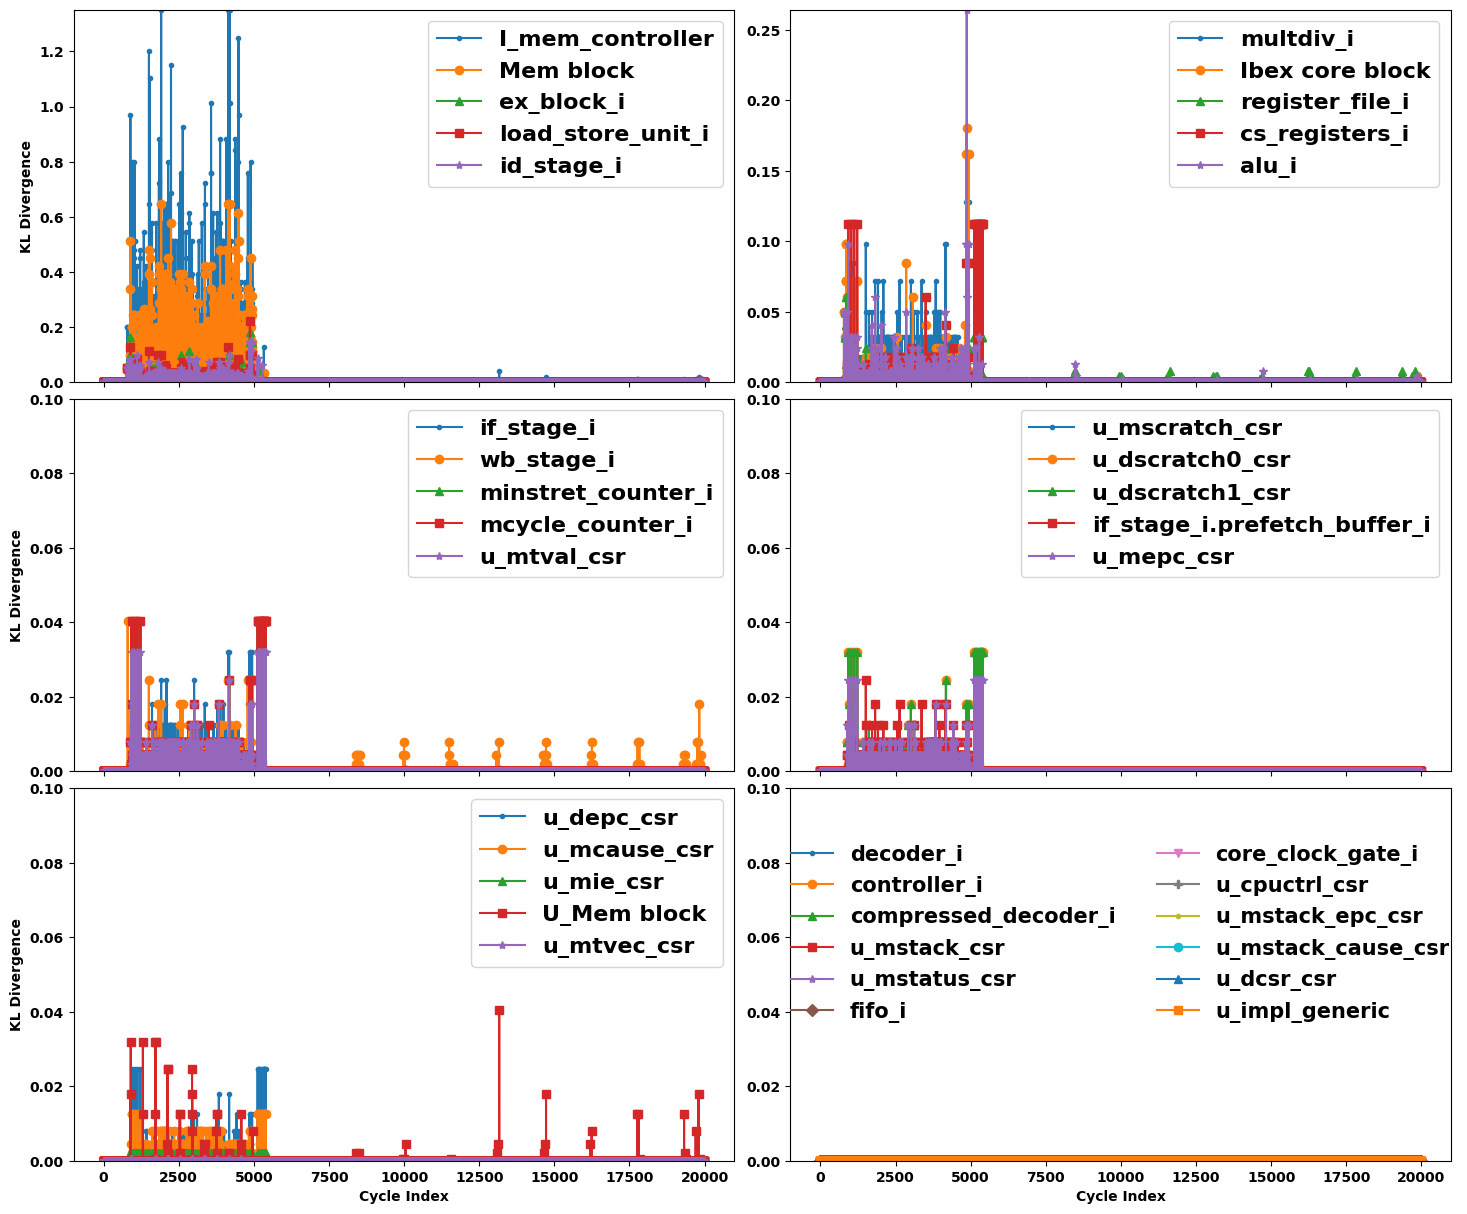

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Load
import pickle
with open("/home/abish/chipwhisperer/jupyter/modules_kl.pkl", "rb") as f:
    modules_kl = pickle.load(f)
###############################################################################
# 1) Gather (module_path, kl_vals, mean_kl) and sort descending
###############################################################################
modules_list = []
for mp, kl_vals in modules_kl.items():
    # Scale KL values
    kl_vals = kl_vals / 1e21
    mean_kl = np.mean(kl_vals)
    modules_list.append((mp, kl_vals, mean_kl))

# Sort by descending mean KL
modules_list.sort(key=lambda x: x[2], reverse=True)

###############################################################################
# 2) Skip certain modules and separate all-zero modules
###############################################################################
skip_modules_exact = {
    "Proact_test_bench.u_top",
    "Proact_test_bench.uut",
    "(root)",
    "Proact_test_bench"
}

zero_modules = []
nonzero_modules = []
for (mp, kl_vals, mean_kl) in modules_list:
    if mp in skip_modules_exact:
        continue
    if np.allclose(kl_vals, 0.0):
        zero_modules.append((mp, kl_vals, mean_kl))
    else:
        nonzero_modules.append((mp, kl_vals, mean_kl))

###############################################################################
# 3) Build “chunks” of size 5 for the nonzero modules, plus one chunk for zeros
###############################################################################
chunk_size = 5
chunks = []

for start_idx in range(0, len(nonzero_modules), chunk_size):
    subchunk = nonzero_modules[start_idx : start_idx + chunk_size]
    chunks.append(subchunk)

# Put all zero modules together as a final chunk (if any)
if len(zero_modules) > 0:
    chunks.append(zero_modules)

###############################################################################
# 5) Shorten module names or rename them altogether
###############################################################################
def shorten_module_name(full_path):
    # Exact overrides first:
    if full_path == "instruction_mem_controller.u_mem.mem0":
        return "Mem block"
    if full_path == "Proact_test_bench.u_top.core_clock_gate_i.u_impl_generic":
        return "u_impl_generic"
    if full_path == "Proact_test_bench.u_top.core_clock_gate_i":
        return "core_clock_gate_i"
    if full_path == "instruction_mem_controller.u_mem":
        return "U_Mem block"
    if full_path == "Proact_test_bench.u_ibex_core":
        return "Ibex core block"
    if full_path == "instruction_mem_controller":
        return "I_mem_controller"

    # Remove these prefixes if they appear:
    prefixes = [
        "Proact_test_bench.u_top.",
        "Proact_test_bench.uut.",
        "Proact_test_bench.u_ibex_core."
    ]
    short_name = full_path
    for p in prefixes:
        short_name = short_name.replace(p, "")

    return short_name if short_name else "(root)"

###############################################################################
# 6) Create the 2×3 figure (horizontal layout)
###############################################################################
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 12))
axes_flat = axes.flatten()

max_subplots = 6  # Only up to 6 subplots total

# Markers for each line
markers = [".", "o", "^", "s", "*", "D", "v", "P"]

###############################################################################
# 7) Plot each chunk in its subplot with local scaling
###############################################################################
for idx, chunk_data in enumerate(chunks[:max_subplots]):
    ax = axes_flat[idx]
    row, col = divmod(idx, 3)  # row ∈ {0,1}, col ∈ {0,1,2}

    # Collect all values in this chunk to determine local y-limit
    all_vals_in_chunk = []

    for i, (mp, kl_vals, mean_kl) in enumerate(chunk_data):
        label = shorten_module_name(mp)
        marker_style = markers[i % len(markers)]
        ax.plot(kl_vals, marker=marker_style, linestyle='-', label=label)
        all_vals_in_chunk.extend(kl_vals)

    # Automatic local y-scale (start at 0, go up to max of chunk’s data)
    if all_vals_in_chunk:
        local_max = max(all_vals_in_chunk)
        if local_max < 0.1:
            local_max = 0.1
        ax.set_ylim([0, local_max])
    else:
        ax.set_ylim([0, 1])

    # Hide or show labels based on row/column
    # - No x-axis ticks/labels for row=0
    if (((row == 1) & (col == 1))|((row == 1) & (col == 2))):
        ax.set_xlabel("Cycle Index", fontweight='bold')
    else:
        ax.set_xlabel("")
        ax.set_xticklabels([])

    # - Only column=0 shows y-axis label; columns 1 & 2 remove label but keep ticks
    if (((row == 0) & (col == 0))|((row == 0) & (col == 2))|((row == 1) & (col == 1))):
        ax.set_ylabel("KL Divergence", fontweight='bold')
    else:
        ax.set_ylabel("")  # No label, but keep numeric y ticks

    # Show legend with smaller font
    legend = ax.legend(loc="upper right", fontsize=16)
    # Make legend text bold
    for text in legend.get_texts():
        text.set_fontweight('bold')

    # Make tick labels bold
    for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
        tick_label.set_fontweight('bold')

# Show legend with smaller font
    # Show legend with smaller font
if idx == len(chunks[:max_subplots]) - 1:
    # For the last subplot: horizontal legend, 3 items per row
    legend = ax.legend(
        loc="upper center",
        bbox_to_anchor=(00.5, 0.9),
        ncol=2,  # 👈 3 items per row
        fontsize=15,
        frameon=False
    )
else:
    legend = ax.legend(loc="upper right", fontsize=12)

for text in legend.get_texts():
    text.set_fontweight('bold')
###############################################################################
# 8) Remove extra subplots if fewer than 6 chunks
###############################################################################
if len(chunks) < max_subplots:
    for extra_idx in range(len(chunks), max_subplots):
        axes_flat[extra_idx].axis("off")

###############################################################################
# 9) Make figure background transparent
###############################################################################
fig.patch.set_facecolor("none")
for ax in axes_flat:
    ax.set_facecolor("none")

###############################################################################
# 10) Adjust spacing so y-ticks remain visible in columns 2 and 3
###############################################################################
# If wspace=0 is too tight, the y-ticks in cols 2 and 3 can get clipped.
# Increase wspace slightly (e.g. 0.05) or use tight_layout with small pad:
fig.subplots_adjust(wspace=0.05, hspace=0)
plt.tight_layout(pad=0.2)

# Save as PDF with transparent background and tight bounding box
#f#ig.savefig("kl_2x3_fplot2_asis.pdf", bbox_inches="tight", transparent=True)
# Save as SVG similarly
#<<<<<<<fig.savefig("kl_2x3_fplotxx_asis.svg", bbox_inches="tight", transparent=True)
#fig.savefig("kl_2x3_fplotxx_asis.png", bbox_inches="tight", transparent=True)
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42  # Embed fonts, don't convert to paths
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'  # For SVG output

# Rasterize all plotted lines to speed up PDF rendering
for ax in axes_flat:
    for line in ax.get_lines():
        line.set_rasterized(True)

# Save optimized PDF
fig.savefig("kl_2x3_fplot_optimized.pdf", bbox_inches="tight", transparent=True, dpi=300)

# Show on screen (optional)
plt.show()
